# Quantum-Classical Hybrid MNIST Digit Classification
## A Comprehensive Benchmark for Quantum Machine Learning

This notebook implements a full quantum-classical hybrid benchmark on the MNIST dataset,
including exploratory data analysis, multiple ML architectures, noise robustness testing,
and comprehensive evaluation metrics.

## 0) Installation
Install required packages (run once if needed)

In [1]:
# Run once if needed
# !pip install numpy pandas matplotlib seaborn scikit-learn scipy imbalanced-learn

## 1) Imports & Global Config

In [2]:
import time, warnings, itertools, os, json, copy
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

from typing import Dict, Any, List, Tuple, Optional
from dataclasses import dataclass, field
from collections import Counter

# ── Sklearn ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              confusion_matrix, roc_curve, precision_recall_curve,
                              classification_report)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.stats import ttest_rel, wilcoxon, mannwhitneyu, friedmanchisquare

# ── Imbalanced-learn ──────────────────────────────────────
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.combine import SMOTETomek
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False
    print("[WARN] imbalanced-learn not found – using fallback resampling")

GLOBAL_SEED = 42
OUT_DIR = "outputs/mnist/"
RES_DIR = "results/mnist/"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

def set_seed(seed=GLOBAL_SEED):
    np.random.seed(seed)

set_seed()
print("Imports done. Output dirs created.")


Imports done. Output dirs created.


## 2) Data Loading & EDA

In [3]:
# ── Load MNIST dataset ──────────────────────────────────
from sklearn.datasets import load_digits

digits = load_digits()
X_full = digits.data
y_full = digits.target

print("Shape:", X_full.shape)
print(f"Features: {X_full.shape[1]} (8x8 pixel images)\nClasses: {len(np.unique(y_full))} (digits 0-9)")
print("\nClass distribution:")
for digit in range(10):
    count = np.sum(y_full == digit)
    print(f"  Digit {digit}: {count} samples")
print(f"\nMissing values: {np.isnan(X_full).sum().sum() if hasattr(X_full, 'sum') else 0}")
print(f"\nFeature statistics:\nMin: {X_full.min():.2f}, Max: {X_full.max():.2f}, Mean: {X_full.mean():.2f}")

# Create binary classification task: digits 0-4 vs 5-9
y_binary = (y_full >= 5).astype(int)
X_df = pd.DataFrame(X_full, columns=[f"pixel_{i}" for i in range(X_full.shape[1])])
y_s = pd.Series(y_binary)

print(f"\nBinary task: Digits 0-4 vs 5-9")
print(f"Class 0 (0-4): {(y_binary==0).sum()}, Class 1 (5-9): {(y_binary==1).sum()}")
print(f"Balance ratio: {(y_binary==0).sum() / (y_binary==1).sum():.2f}:1")


Shape: (1797, 64)
Features: 64 (8x8 pixel images)
Classes: 10 (digits 0-9)

Class distribution:
  Digit 0: 178 samples
  Digit 1: 182 samples
  Digit 2: 177 samples
  Digit 3: 183 samples
  Digit 4: 181 samples
  Digit 5: 182 samples
  Digit 6: 181 samples
  Digit 7: 179 samples
  Digit 8: 174 samples
  Digit 9: 180 samples

Missing values: 0

Feature statistics:
Min: 0.00, Max: 16.00, Mean: 4.88

Binary task: Digits 0-4 vs 5-9
Class 0 (0-4): 901, Class 1 (5-9): 896
Balance ratio: 1.01:1


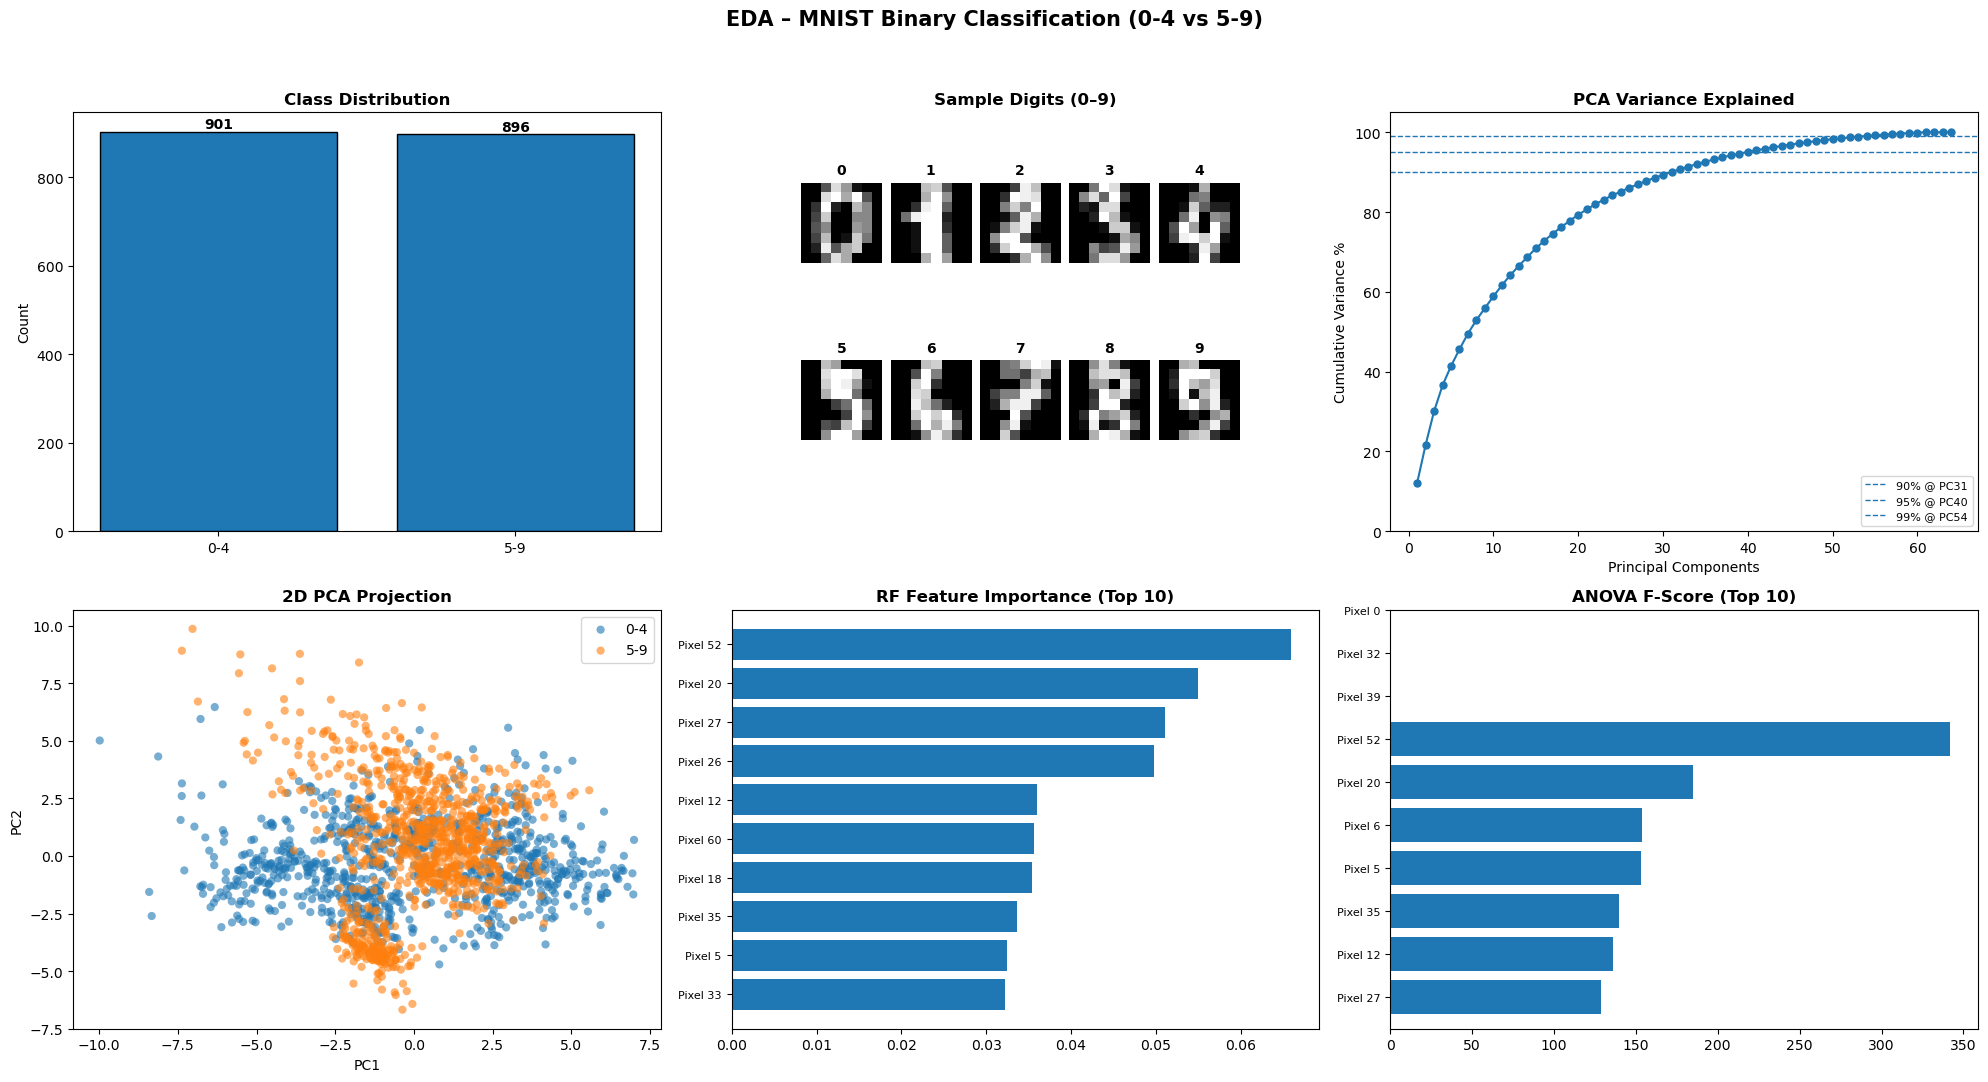

EDA plot saved: results/mnist/eda_overview.png


In [5]:
scaler_eda = StandardScaler()
Xs_eda = scaler_eda.fit_transform(X_df)

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("EDA – MNIST Binary Classification (0-4 vs 5-9)", fontsize=15, fontweight="bold")

# =======================
# 1) Class distribution
# =======================
cnts = y_s.value_counts().rename({0: "0-4", 1: "5-9"})
bars = axes[0, 0].bar(cnts.index.astype(str), cnts.values, edgecolor="k")  # no fixed colors
for bar, v in zip(bars, cnts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, v + max(cnts.values) * 0.01, str(v),
                    ha="center", fontweight="bold")
axes[0, 0].set_title("Class Distribution", fontweight="bold")
axes[0, 0].set_ylabel("Count")

# ==========================================
# 2) Sample digits visualization (0–9 grid)
# FIX: don't call axes[0,1].subplot (doesn't exist)
# We create an inset grid inside axes[0,1]
# ==========================================
axes[0, 1].set_title("Sample Digits (0–9)", fontweight="bold")
axes[0, 1].axis("off")

# Inset grid area within axes[0,1] using its bounding box
bbox = axes[0, 1].get_position()
left, bottom, width, height = bbox.x0, bbox.y0, bbox.width, bbox.height

nrows, ncols = 2, 5
pad_w = 0.02 * width
pad_h = 0.08 * height
cell_w = (width - pad_w * (ncols + 1)) / ncols
cell_h = (height - pad_h * (nrows + 1)) / nrows

# Pick the correct reshape side automatically (8x8 for sklearn digits, 28x28 for MNIST)
side = int(np.sqrt(X_full.shape[1]))
assert side * side == X_full.shape[1], f"X_full has {X_full.shape[1]} features; can't reshape to square image."

for idx, digit in enumerate(range(10)):
    sample_idx = np.where(y_full == digit)[0][0]
    img = X_full[sample_idx].reshape(side, side)

    r = idx // ncols
    c = idx % ncols

    ax_in = fig.add_axes([
        left + pad_w + c * (cell_w + pad_w),
        bottom + height - (pad_h + (r + 1) * cell_h + r * pad_h),
        cell_w,
        cell_h
    ])
    ax_in.imshow(img, cmap="gray")
    ax_in.set_title(str(digit), fontsize=10, fontweight="bold")
    ax_in.axis("off")

# ==========================
# 3) PCA variance explained
# ==========================
pca_full = PCA(random_state=GLOBAL_SEED).fit(Xs_eda)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[0, 2].plot(range(1, len(cumvar) + 1), cumvar * 100, marker="o", ms=5)
for thresh in [0.90, 0.95, 0.99]:
    n = np.searchsorted(cumvar, thresh) + 1
    axes[0, 2].axhline(thresh * 100, ls="--", lw=1, label=f"{thresh*100:.0f}% @ PC{n}")
axes[0, 2].set_xlabel("Principal Components")
axes[0, 2].set_ylabel("Cumulative Variance %")
axes[0, 2].set_title("PCA Variance Explained", fontweight="bold")
axes[0, 2].legend(fontsize=8)
axes[0, 2].set_ylim([0, 105])

# =======================
# 4) 2D PCA scatter
# =======================
pca2 = PCA(2, random_state=GLOBAL_SEED).fit_transform(Xs_eda)
for lbl, name in [(0, "0-4"), (1, "5-9")]:
    m = (y_s == lbl)
    axes[1, 0].scatter(pca2[m, 0], pca2[m, 1], label=name, alpha=0.6, s=35, edgecolors="none")
axes[1, 0].set_title("2D PCA Projection", fontweight="bold")
axes[1, 0].legend()
axes[1, 0].set_xlabel("PC1")
axes[1, 0].set_ylabel("PC2")

# =================================
# 5) RF Feature importance (Top 10)
# =================================
rf_eda = RandomForestClassifier(n_estimators=200, random_state=GLOBAL_SEED, n_jobs=-1)
rf_eda.fit(Xs_eda, y_s)
imp = rf_eda.feature_importances_
top_idx = np.argsort(imp)[::-1][:10]

axes[1, 1].barh(range(len(top_idx)), imp[top_idx][::-1])
axes[1, 1].set_yticks(range(len(top_idx)))
axes[1, 1].set_yticklabels([f"Pixel {i}" for i in top_idx[::-1]], fontsize=8)
axes[1, 1].set_title("RF Feature Importance (Top 10)", fontweight="bold")

# ============================
# 6) ANOVA F-score (Top 10)
# ============================
f_scores, _ = f_classif(Xs_eda, y_s)
idx_f = np.argsort(f_scores)[::-1][:10]

axes[1, 2].barh(range(len(idx_f)), f_scores[idx_f][::-1])
axes[1, 2].set_yticks(range(len(idx_f)))
axes[1, 2].set_yticklabels([f"Pixel {i}" for i in idx_f[::-1]], fontsize=8)
axes[1, 2].set_title("ANOVA F-Score (Top 10)", fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save + show
plt.savefig(RES_DIR + "eda_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("EDA plot saved:", RES_DIR + "eda_overview.png")

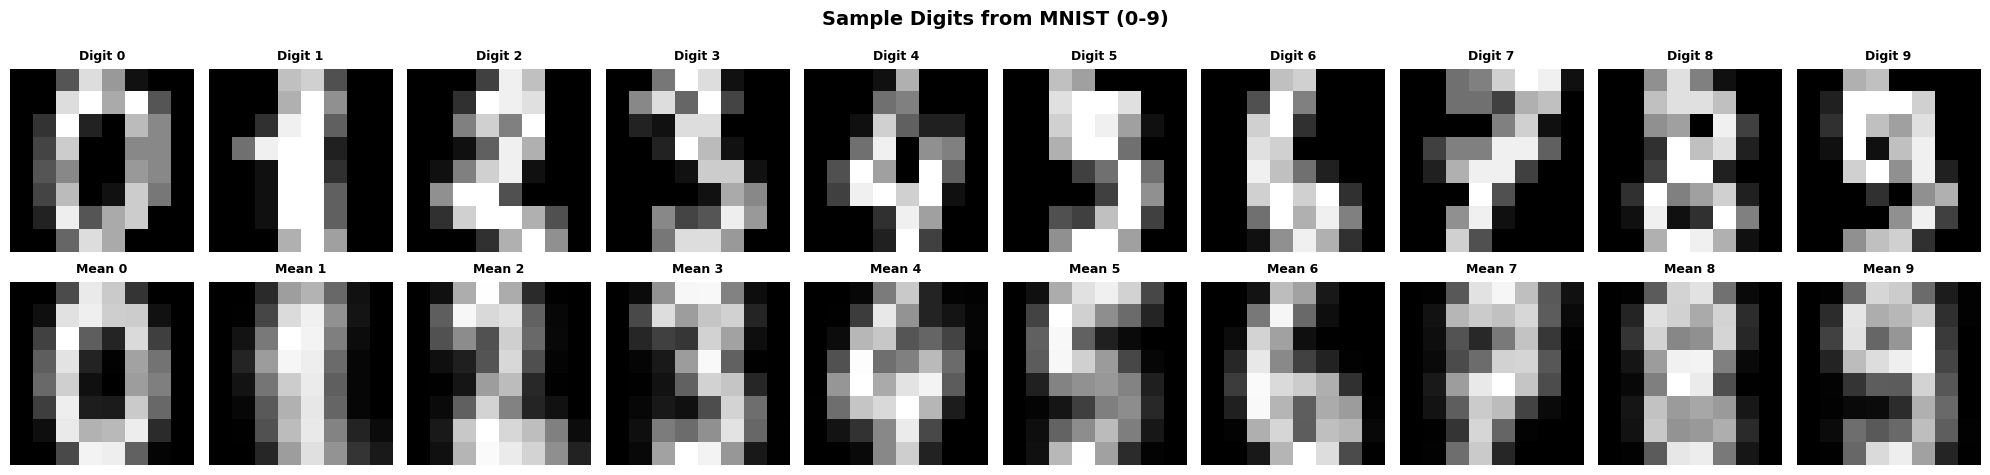

Digit samples plot saved.


In [6]:
# ── Digit samples visualization ────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle("Sample Digits from MNIST (0-9)", fontsize=14, fontweight="bold")

for digit in range(10):
    sample_idx = np.where(y_full == digit)[0][0]
    img = X_full[sample_idx].reshape(8, 8)
    axes[0, digit].imshow(img, cmap="gray")
    axes[0, digit].set_title(f"Digit {digit}", fontweight="bold", fontsize=9)
    axes[0, digit].axis("off")

    # Show mean image for each class
    mean_img = X_full[y_full == digit].mean(axis=0).reshape(8, 8)
    axes[1, digit].imshow(mean_img, cmap="gray")
    axes[1, digit].set_title(f"Mean {digit}", fontweight="bold", fontsize=9)
    axes[1, digit].axis("off")

plt.tight_layout()
plt.savefig(RES_DIR + "digit_samples.png", dpi=120, bbox_inches="tight")
plt.show()
print("Digit samples plot saved.")


## 3) Adaptive Feature Selection

In [7]:
def select_relevant_features(X: pd.DataFrame, y: pd.Series,
                              threshold_cumvar: float = 0.95,
                              min_features: int = 4) -> Tuple[List[str], np.ndarray]:
    """
    Multi-method feature selection:
    1. ANOVA filter: keep features with F-score above median
    2. RF importance filter: keep features with importance > mean
    3. Mutual information filter: keep features above median
    4. Union of 2+ method agreement
    Returns: (selected_feature_names, feature_indices)
    """
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    f_scores, _ = f_classif(Xs, y)
    anova_mask = f_scores >= np.median(f_scores)

    rf = RandomForestClassifier(300, random_state=GLOBAL_SEED).fit(Xs, y)
    rf_mask = rf.feature_importances_ >= rf.feature_importances_.mean()

    mi_scores = mutual_info_classif(Xs, y, random_state=GLOBAL_SEED)
    mi_mask = mi_scores >= np.median(mi_scores)

    vote = anova_mask.astype(int) + rf_mask.astype(int) + mi_mask.astype(int)
    selected_mask = vote >= 2

    if selected_mask.sum() < min_features:
        top_idx = np.argsort(f_scores)[::-1][:min_features]
        selected_mask = np.zeros(len(f_scores), dtype=bool)
        selected_mask[top_idx] = True

    selected_names = X.columns[selected_mask].tolist()
    selected_idx = np.where(selected_mask)[0]

    pca_check = PCA(random_state=GLOBAL_SEED).fit(Xs[:, selected_idx])
    covered = np.sum(pca_check.explained_variance_ratio_)

    print(f"Feature selection: {selected_mask.sum()}/{len(f_scores)} features selected")
    print(f"  Variance covered by selected features: {covered:.3f}")

    return selected_names, selected_idx


relevant_features, relevant_idx = select_relevant_features(X_df, y_s)
X_relevant = X_df[relevant_features].values
print(f"\nUsing {len(relevant_features)} relevant features for quantum models")
print(f"Full feature set ({X_df.shape[1]}) used for classical models")


Feature selection: 20/64 features selected
  Variance covered by selected features: 1.000

Using 20 relevant features for quantum models
Full feature set (64) used for classical models


## 4) Preprocessing & Resampling Utilities

In [8]:
def apply_resampling(X, y, strategy="smote", seed=GLOBAL_SEED):
    if strategy == "none":
        return X, y
    if HAS_IMBLEARN:
        sampler = SMOTE(random_state=seed) if strategy=="smote" else SMOTETomek(random_state=seed)
        return sampler.fit_resample(X, y)
    # fallback minority oversampling
    rng = np.random.default_rng(seed)
    minority = np.where(y==1)[0]
    majority = np.where(y==0)[0]
    if len(minority) == 0 or len(majority) == 0:
        return X, y
    dup = rng.choice(minority, size=max(0, len(majority)-len(minority)), replace=True)
    if len(dup) > 0:
        Xr = np.vstack([X, X[dup]])
        yr = np.concatenate([y, y[dup]])
        perm = rng.permutation(len(yr))
        return Xr[perm], yr[perm]
    return X, y


def preprocess_dataset(X, y, n_features, seed=GLOBAL_SEED, test_size=0.2,
                        resample="smote", use_pca=True):
    """
    Split → resample → scale → (optionally PCA to n_features).
    Returns: Xtr, Xte, ytr, yte
    """
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size,
                                            stratify=y, random_state=seed)
    if resample != "none":
        Xtr, ytr = apply_resampling(Xtr, ytr, strategy=resample, seed=seed)

    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Xtr)
    Xte = scaler.transform(Xte)

    if use_pca and n_features < Xtr.shape[1]:
        pca = PCA(n_components=n_features, random_state=seed)
        Xtr = pca.fit_transform(Xtr)
        Xte = pca.transform(Xte)

    return Xtr, Xte, ytr, yte


print("Preprocessing functions ready.")


Preprocessing functions ready.


## 5) Quantum Feature Encoders & Numpy Quantum Simulators

In [9]:
class ZZFeatureEncoder:
    """ZZFeatureMap-style encoding: rotations + pairwise ZZ interactions."""
    def __init__(self, n_qubits):
        self.n_qubits = n_qubits

    def encode(self, x):
        x = x[:self.n_qubits]
        feats = list(x)
        for i in range(self.n_qubits - 1):
            feats.append((np.pi - x[i]) * (np.pi - x[i+1]))
        return np.array(feats)

    def encode_batch(self, X):
        return np.array([self.encode(xi) for xi in X])

    @property
    def dim(self):
        return self.n_qubits + (self.n_qubits - 1)


class PauliEncoder:
    """Pauli-style: includes cross terms up to 3-body."""
    def __init__(self, n_qubits):
        self.n_qubits = n_qubits

    def encode(self, x):
        x = x[:self.n_qubits]
        feats = list(x)
        for i in range(self.n_qubits-1):
            feats.append(x[i]*x[i+1])
        for i in range(self.n_qubits-2):
            feats.append(x[i]*x[i+1]*x[i+2])
        return np.array(feats)

    def encode_batch(self, X):
        return np.array([self.encode(xi) for xi in X])

    @property
    def dim(self):
        return self.n_qubits + (self.n_qubits-1) + (self.n_qubits-2)


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


class NumpyVQC(BaseEstimator, ClassifierMixin):
    """Variational Quantum Classifier (numpy simulation)."""
    def __init__(self, n_qubits=4, reps=2, shots=512, seed=GLOBAL_SEED,
                 maxiter=100, encoder="zz"):
        self.n_qubits=n_qubits; self.reps=reps; self.shots=shots
        self.seed=seed; self.maxiter=maxiter; self.encoder=encoder

    def _get_encoder(self):
        return ZZFeatureEncoder(self.n_qubits) if self.encoder=="zz" else PauliEncoder(self.n_qubits)

    def _shot_noise(self, p):
        return np.clip(p + np.random.randn(*p.shape)/np.sqrt(self.shots), 0, 1)

    def _loss(self, params, Xe, y):
        p = self._shot_noise(sigmoid(Xe @ params[:-1] + params[-1]))
        p = np.clip(p, 1e-7, 1-1e-7)
        return -np.mean(y*np.log(p) + (1-y)*np.log(1-p))

    def fit(self, X, y):
        set_seed(self.seed)
        enc = self._get_encoder()
        Xe = enc.encode_batch(X)
        d = enc.dim
        params = np.random.normal(0, 0.3, d+1)
        self.loss_curve_ = []
        lr = 0.15
        for it in range(self.maxiter):
            self.loss_curve_.append(self._loss(params, Xe, y))
            grad = np.zeros_like(params)
            for i in range(len(params)):
                p_p = params.copy(); p_p[i] += np.pi/2
                p_m = params.copy(); p_m[i] -= np.pi/2
                grad[i] = (self._loss(p_p,Xe,y) - self._loss(p_m,Xe,y)) / 2
            params -= lr * grad
            lr *= 0.997
        self.params_ = params
        self.enc_ = enc
        self.classes_ = np.array([0,1])
        return self

    def predict_proba(self, X):
        Xe = self.enc_.encode_batch(X)
        p = sigmoid(Xe @ self.params_[:-1] + self.params_[-1])
        return np.column_stack([1-p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:,1] >= 0.5).astype(int)


class NumpyQCNN(NumpyVQC):
    """QCNN: conv+pool on top of ZZ encoding."""
    def __init__(self, **kw):
        super().__init__(**kw)

    def _conv_pool(self, Xe):
        if Xe.shape[1] < 2:
            return Xe
        conv = np.array([Xe[:,i]*Xe[:,i+1] for i in range(Xe.shape[1]-1)]).T
        pool_size = max(1, conv.shape[1]//2)
        pool = np.array([conv[:,2*i:2*i+2].mean(1) for i in range(pool_size)]).T
        return np.hstack([Xe, conv, pool])

    def fit(self, X, y):
        set_seed(self.seed)
        enc = self._get_encoder()
        Xe_raw = enc.encode_batch(X)
        Xe = self._conv_pool(Xe_raw)
        d = Xe.shape[1]
        params = np.random.normal(0, 0.3, d+1)
        self.loss_curve_ = []
        lr = 0.15
        for it in range(self.maxiter):
            p = self._shot_noise(sigmoid(Xe @ params[:-1] + params[-1]))
            p = np.clip(p, 1e-7, 1-1e-7)
            loss = -np.mean(y*np.log(p) + (1-y)*np.log(1-p))
            self.loss_curve_.append(loss)
            grad = np.zeros_like(params)
            eps = 1e-4
            for i in range(len(params)):
                pp = params.copy(); pp[i]+=eps
                pm = params.copy(); pm[i]-=eps
                lp = -np.mean(y*np.log(np.clip(sigmoid(Xe@pp[:-1]+pp[-1]),1e-7,1-1e-7))
                              + (1-y)*np.log(np.clip(1-sigmoid(Xe@pp[:-1]+pp[-1]),1e-7,1-1e-7)))
                lm = -np.mean(y*np.log(np.clip(sigmoid(Xe@pm[:-1]+pm[-1]),1e-7,1-1e-7))
                              + (1-y)*np.log(np.clip(1-sigmoid(Xe@pm[:-1]+pm[-1]),1e-7,1-1e-7)))
                grad[i] = (lp-lm)/(2*eps)
            params -= lr*grad; lr*=0.997
        self.params_ = params; self.enc_ = enc; self.classes_ = np.array([0,1])
        self._Xe_train = Xe
        return self

    def predict_proba(self, X):
        Xe_raw = self.enc_.encode_batch(X)
        Xe = self._conv_pool(Xe_raw)
        p = sigmoid(Xe @ self.params_[:-1] + self.params_[-1])
        return np.column_stack([1-p, p])


class NumpyQAOA(NumpyVQC):
    """QAOA-inspired: alternating cost/mixer layers."""
    def _encode_qaoa(self, Xe):
        cost = np.tanh(Xe)
        mixer = np.roll(cost, 1, axis=1) * cost
        return np.hstack([cost, mixer])

    def fit(self, X, y):
        set_seed(self.seed)
        enc = self._get_encoder()
        Xe = self._encode_qaoa(enc.encode_batch(X))
        d = Xe.shape[1]
        params = np.random.normal(0, 0.3, d+1)
        self.loss_curve_ = []
        lr = 0.12
        for it in range(self.maxiter):
            p = self._shot_noise(sigmoid(Xe @ params[:-1] + params[-1]))
            p = np.clip(p, 1e-7, 1-1e-7)
            self.loss_curve_.append(-np.mean(y*np.log(p)+(1-y)*np.log(1-p)))
            grad = np.zeros_like(params)
            for i in range(len(params)):
                pp=params.copy(); pp[i]+=np.pi/2
                pm=params.copy(); pm[i]-=np.pi/2
                f = lambda p_: -np.mean(y*np.log(np.clip(self._shot_noise(
                    sigmoid(Xe@p_[:-1]+p_[-1])),1e-7,1-1e-7))
                    +(1-y)*np.log(np.clip(1-self._shot_noise(
                    sigmoid(Xe@p_[:-1]+p_[-1])),1e-7,1-1e-7)))
                grad[i] = (f(pp)-f(pm))/2
            params -= lr*grad; lr*=0.997
        self.params_=params; self.enc_=enc; self.classes_=np.array([0,1])
        return self

    def predict_proba(self, X):
        Xe = self._encode_qaoa(self.enc_.encode_batch(X))
        p = sigmoid(Xe @ self.params_[:-1] + self.params_[-1])
        return np.column_stack([1-p, p])


class NumpyQKernelSVM(BaseEstimator, ClassifierMixin):
    """Quantum Kernel SVM: fidelity kernel via inner-product of encoded states."""
    def __init__(self, n_qubits=4, C=1.0, seed=GLOBAL_SEED):
        self.n_qubits=n_qubits; self.C=C; self.seed=seed

    def _kernel(self, X1, X2):
        enc = ZZFeatureEncoder(self.n_qubits)
        Z1 = enc.encode_batch(X1)
        Z2 = enc.encode_batch(X2)
        n1 = np.linalg.norm(Z1, axis=1, keepdims=True) + 1e-10
        n2 = np.linalg.norm(Z2, axis=1, keepdims=True) + 1e-10
        K = (Z1/n1) @ (Z2/n2).T
        return K**2

    def fit(self, X, y):
        self.X_train_ = X
        self.y_train_ = y
        K = self._kernel(X, X)
        self.svm_ = SVC(kernel="precomputed", C=self.C, probability=True,
                         random_state=self.seed)
        self.svm_.fit(K, y)
        self.classes_ = np.array([0,1])
        self.loss_curve_ = []
        return self

    def predict_proba(self, X):
        K = self._kernel(X, self.X_train_)
        return self.svm_.predict_proba(K)

    def predict(self, X):
        K = self._kernel(X, self.X_train_)
        return self.svm_.predict(K)


print("Numpy quantum simulators ready.")


Numpy quantum simulators ready.


## 6) Hybrid Models

In [10]:
class HybridNet(BaseEstimator, ClassifierMixin):
    """
    Quantum Feature Extractor + Classical MLP.
    Architecture: Input → ZZFeatureMap (numpy) → Classical MLP(32,16) → Output
    """
    def __init__(self, n_qubits=4, hidden=(32,16), seed=GLOBAL_SEED, maxiter=300):
        self.n_qubits=n_qubits; self.hidden=hidden
        self.seed=seed; self.maxiter=maxiter

    def fit(self, X, y):
        enc = ZZFeatureEncoder(self.n_qubits)
        Xe = enc.encode_batch(X)
        X_aug = np.hstack([X[:,:self.n_qubits], Xe])
        self.enc_ = enc
        self.mlp_ = MLPClassifier(hidden_layer_sizes=self.hidden,
                                   max_iter=self.maxiter,
                                   random_state=self.seed,
                                   early_stopping=True)
        self.mlp_.fit(X_aug, y)
        self.loss_curve_ = list(self.mlp_.loss_curve_) if hasattr(self.mlp_,"loss_curve_") else []
        self.classes_ = np.array([0,1])
        return self

    def predict_proba(self, X):
        Xe = self.enc_.encode_batch(X)
        X_aug = np.hstack([X[:,:self.n_qubits], Xe])
        return self.mlp_.predict_proba(X_aug)

    def predict(self, X):
        return (self.predict_proba(X)[:,1] >= 0.5).astype(int)


class QuantumBoost(BaseEstimator, ClassifierMixin):
    """
    Quantum Residual Features + Gradient Boosting Classifier.
    Architecture: Input → [ZZ features || Pauli features || raw] → GradientBoostingClassifier
    """
    def __init__(self, n_qubits=4, n_estimators=100, seed=GLOBAL_SEED):
        self.n_qubits=n_qubits; self.n_estimators=n_estimators; self.seed=seed

    def _quantum_features(self, X):
        zz = ZZFeatureEncoder(self.n_qubits).encode_batch(X)
        pau = PauliEncoder(self.n_qubits).encode_batch(X)
        raw = X[:, :self.n_qubits]
        residual = zz[:, :self.n_qubits] - raw
        return np.hstack([raw, zz, pau, residual])

    def fit(self, X, y):
        Xq = self._quantum_features(X)
        self.gbm_ = GradientBoostingClassifier(n_estimators=self.n_estimators,
                                                random_state=self.seed)
        self.gbm_.fit(Xq, y)
        self.loss_curve_ = list(self.gbm_.train_score_)
        self.classes_ = np.array([0,1])
        return self

    def predict_proba(self, X):
        return self.gbm_.predict_proba(self._quantum_features(X))

    def predict(self, X):
        return self.gbm_.predict(self._quantum_features(X))


class QResNet(BaseEstimator, ClassifierMixin):
    """
    Quantum ResNet: skip connections between quantum layers.
    Architecture:
        Layer 1: ZZ(x)  + x  (skip) → z1
        Layer 2: ZZ(z1) + z1 (skip) → z2
        Stack [z1, z2, x] → Logistic Regression
    """
    def __init__(self, n_qubits=4, seed=GLOBAL_SEED):
        self.n_qubits=n_qubits; self.seed=seed

    def _residual_forward(self, X):
        raw = X[:, :self.n_qubits]
        enc = ZZFeatureEncoder(self.n_qubits)
        z1_q = enc.encode_batch(raw)
        z1 = np.hstack([z1_q, raw])
        z1_norm = StandardScaler().fit_transform(z1[:, :self.n_qubits])
        z2_q = enc.encode_batch(z1_norm)
        z2 = np.hstack([z2_q, z1[:, :self.n_qubits]])
        return np.hstack([raw, z1, z2])

    def fit(self, X, y):
        Xr = self._residual_forward(X)
        self.lr_ = LogisticRegression(max_iter=2000, C=0.5, random_state=self.seed)
        self.lr_.fit(Xr, y)
        self.loss_curve_ = []
        self.classes_ = np.array([0,1])
        return self

    def predict_proba(self, X):
        return self.lr_.predict_proba(self._residual_forward(X))

    def predict(self, X):
        return self.lr_.predict(self._residual_forward(X))


print("Hybrid models ready: HybridNet, QuantumBoost, QResNet")


Hybrid models ready: HybridNet, QuantumBoost, QResNet


## 7) Model Architecture Diagrams

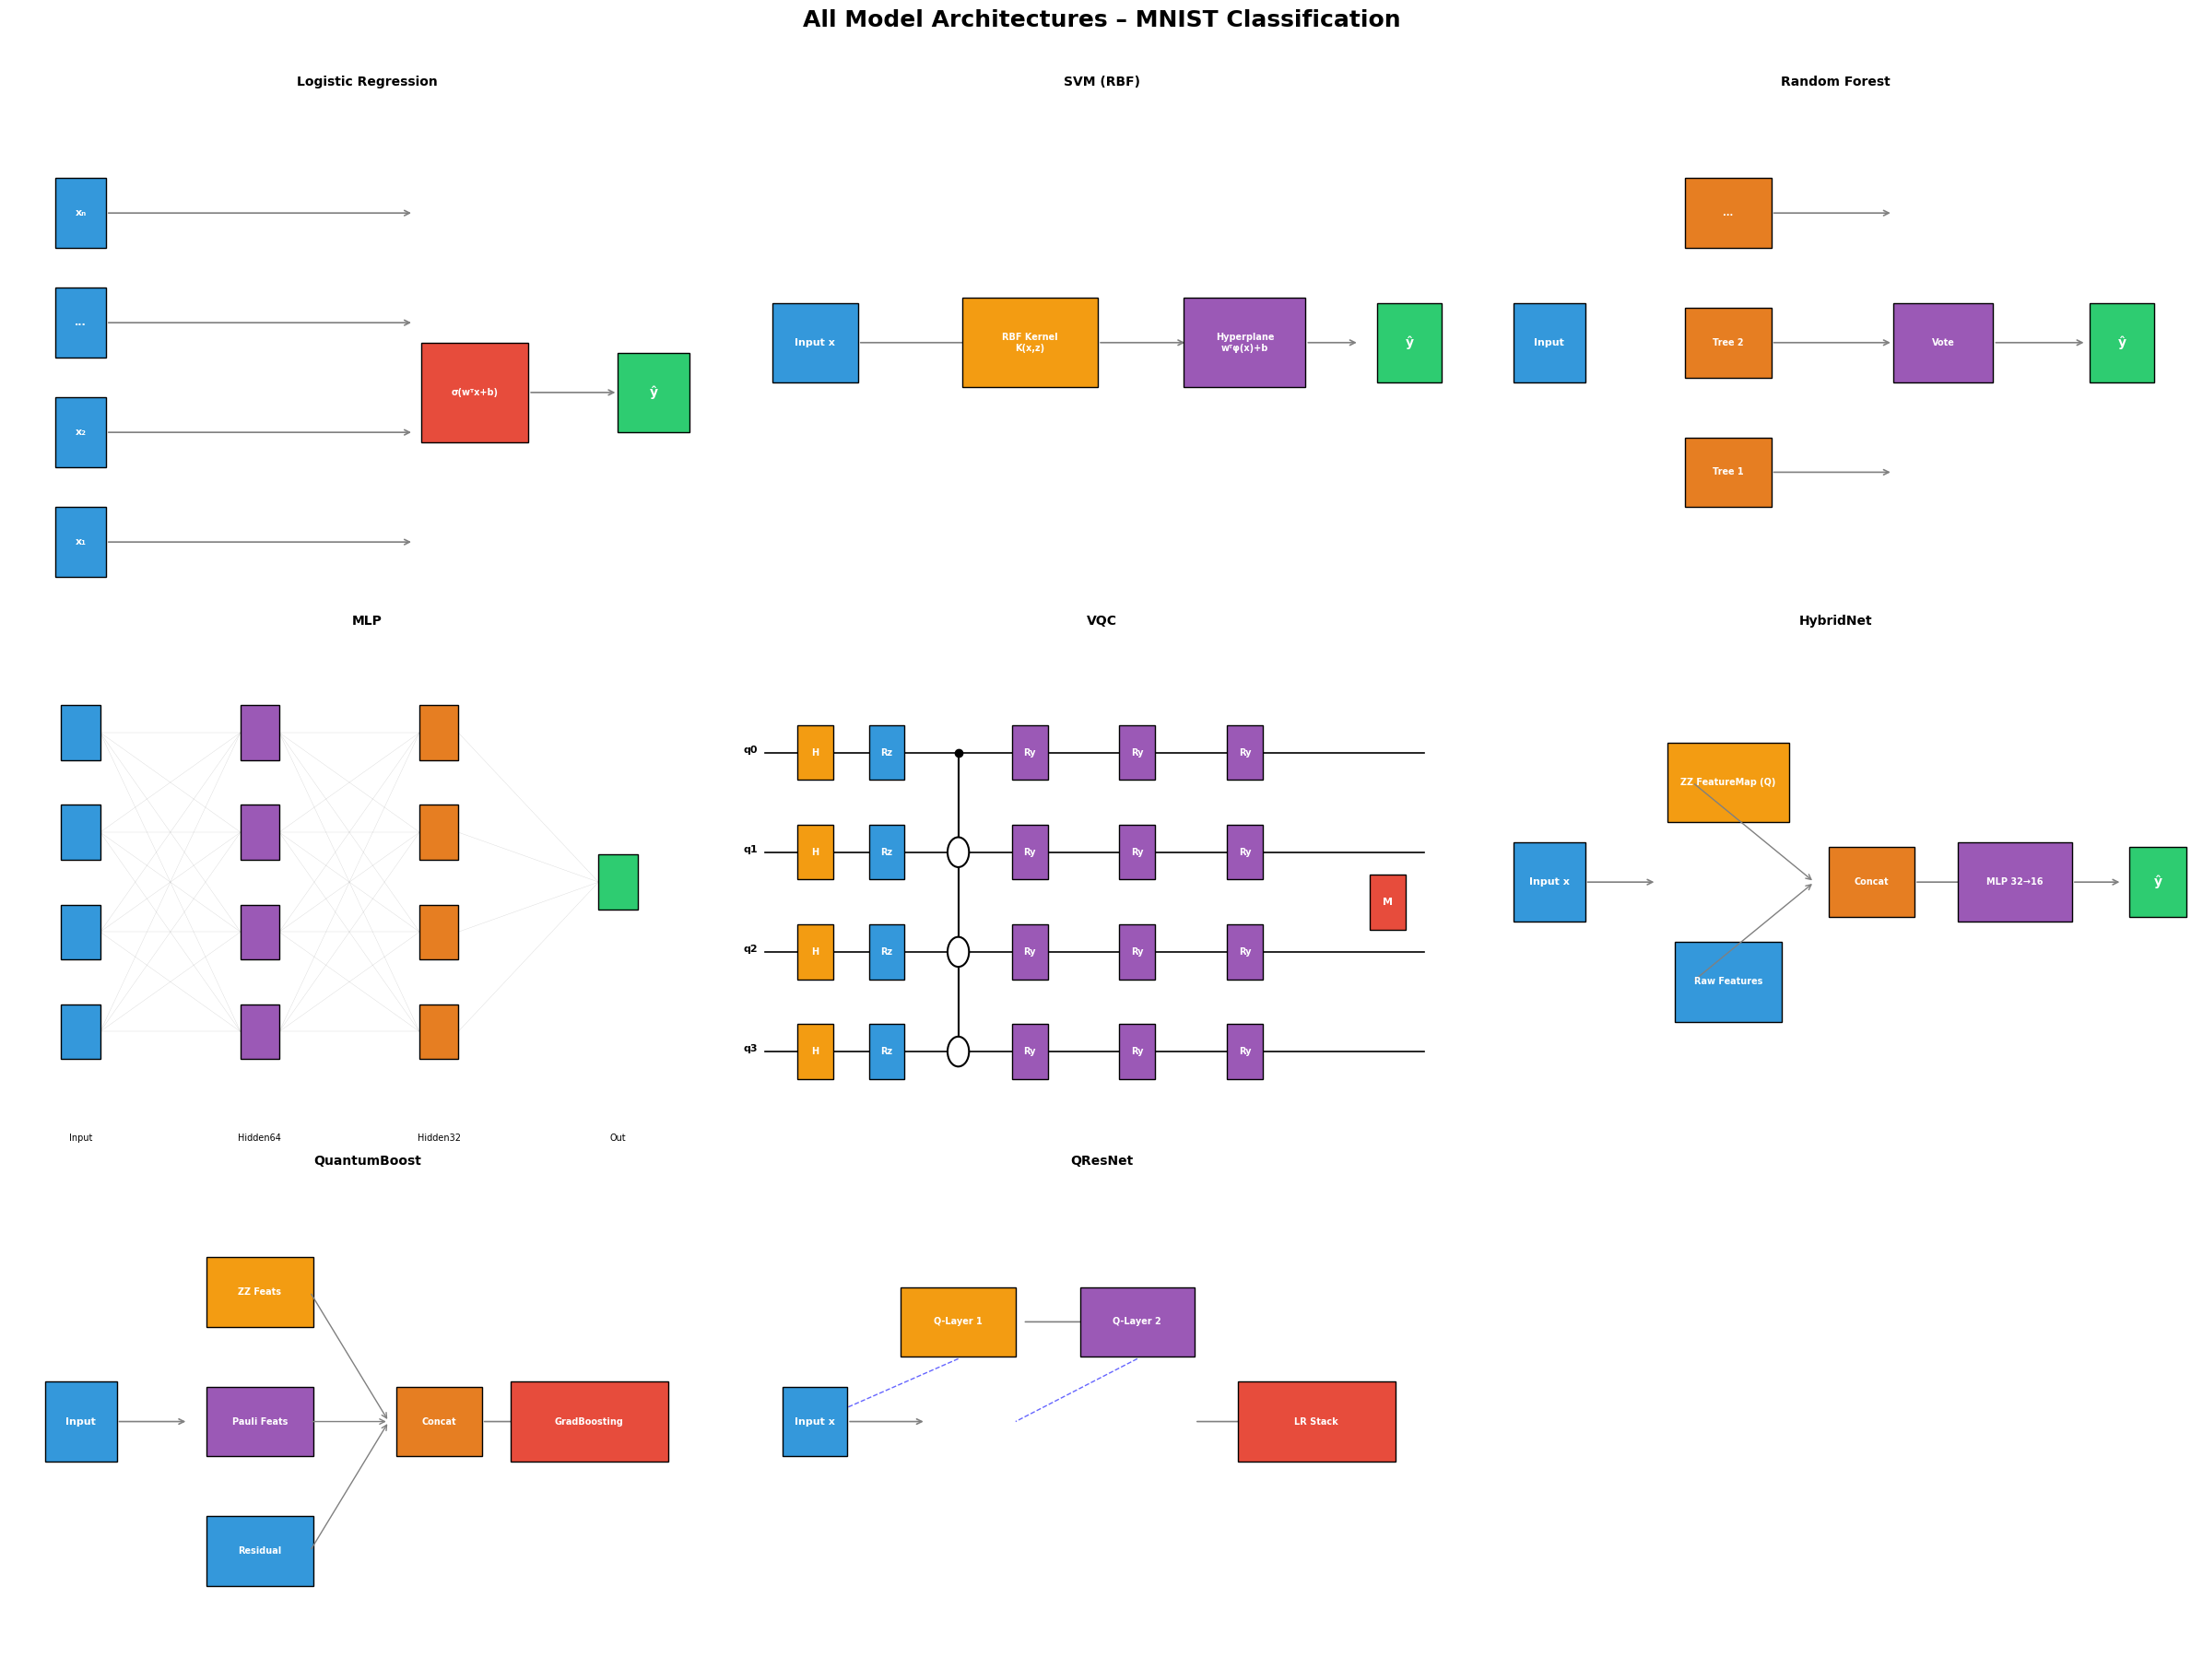

Architecture diagrams saved.


In [11]:
def draw_model_arch(name, ax):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 5)
    ax.axis("off")
    ax.set_title(name, fontsize=10, fontweight="bold", pad=6)

    def box(x, y, w, h, col, txt, fs=8):
        w = float(w); h = float(h)
        ax.add_patch(plt.Rectangle((x-w/2, y-h/2), w, h,
                     facecolor=col, edgecolor="k", lw=1, zorder=3))
        ax.text(x, y, txt, ha="center", va="center", fontsize=fs, zorder=4,
                color="white", fontweight="bold")

    def arrow(x1, x2, y):
        ax.annotate("", xy=(x2, y), xytext=(x1, y),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.2))

    if name == "Logistic Regression":
        for i, t in enumerate(["x₁","x₂","...","xₙ"]):
            y_ = 0.5 + i * 1.1
            box(1, y_, 0.7, 0.7, "#3498db", t)
            arrow(1.35, 5.65, y_)
        box(6.5, 2, 1.5, 1.0, "#e74c3c", "σ(wᵀx+b)", 7)
        arrow(7.25, 8.5, 2)
        box(9, 2, 1.0, 0.8, "#2ecc71", "ŷ", 10)
    elif name == "SVM (RBF)":
        box(1, 2.5, 1.2, 0.8, "#3498db", "Input x", 8)
        arrow(1.6, 3.4, 2.5)
        box(4, 2.5, 1.9, 0.9, "#f39c12", "RBF Kernel\nK(x,z)", 7)
        arrow(4.95, 6.2, 2.5)
        box(7, 2.5, 1.7, 0.9, "#9b59b6", "Hyperplane\nwᵀφ(x)+b", 7)
        arrow(7.85, 8.6, 2.5)
        box(9.3, 2.5, 0.9, 0.8, "#2ecc71", "ŷ", 10)
    elif name == "Random Forest":
        box(1, 2.5, 1.0, 0.8, "#3498db", "Input", 8)
        for i, y_ in enumerate([1.2, 2.5, 3.8]):
            box(3.5, y_, 1.2, 0.7, "#e67e22", f"Tree {i+1}" if i<2 else "...", 7)
            arrow(4.1, 5.8, y_)
        box(6.5, 2.5, 1.4, 0.8, "#9b59b6", "Vote", 7)
        arrow(7.2, 8.5, 2.5)
        box(9, 2.5, 0.9, 0.8, "#2ecc71", "ŷ", 10)
    elif name == "MLP":
        cols = ["#3498db","#9b59b6","#e67e22","#2ecc71"]
        xs = [1, 3.5, 6, 8.5]; ns = [4, 4, 4, 1]
        labels = ["Input","Hidden64","Hidden32","Out"]
        prev_ys = None; prev_x = None
        for xi, ni, col, lbl in zip(xs, ns, cols, labels):
            ys = [2.5 - (ni-1)*0.5 + j for j in range(ni)]
            for y_ in ys:
                box(xi, y_, 0.55, 0.55, col, "", 9)
            ax.text(xi, -0.1, lbl, ha="center", fontsize=7)
            if prev_ys is not None:
                for py in prev_ys:
                    for cy in ys:
                        ax.plot([prev_x+0.27, xi-0.27], [py, cy], color="gray", lw=0.3, alpha=0.3, zorder=1)
            prev_ys = ys; prev_x = xi
    elif name == "VQC":
        for q, y_ in enumerate([3.8, 2.8, 1.8, 0.8]):
            ax.plot([0.3, 9.5], [y_, y_], "k-", lw=1.2)
            ax.text(0.2, y_, f"q{q}", ha="right", fontsize=8, fontweight="bold")
            box(1, y_, 0.5, 0.55, "#f39c12", "H", 7)
            box(2, y_, 0.5, 0.55, "#3498db", "Rz", 7)
            for gx in [4, 5.5, 7]:
                box(gx, y_, 0.5, 0.55, "#9b59b6", "Ry", 7)
        for q in range(3):
            y1 = 3.8 - q; y2 = 2.8 - q
            ax.plot([3, 3], [y1, y2], "k-", lw=1.5)
            ax.plot([3], [y1], "ko", ms=6)
            circ = plt.Circle((3, y2), 0.15, color="white", ec="k", lw=1.5, zorder=3)
            ax.add_patch(circ)
        box(9, 2.3, 0.5, 0.55, "#e74c3c", "M", 8)
    elif name == "HybridNet":
        box(1, 2.5, 1.0, 0.8, "#3498db", "Input x", 8)
        arrow(1.5, 2.5, 2.5)
        box(3.5, 3.5, 1.7, 0.8, "#f39c12", "ZZ FeatureMap (Q)", 7)
        box(3.5, 1.5, 1.5, 0.8, "#3498db", "Raw Features", 7)
        ax.annotate("", xy=(4.7, 2.5), xytext=(3.0, 3.5), arrowprops=dict(arrowstyle="->", color="gray"))
        ax.annotate("", xy=(4.7, 2.5), xytext=(3.0, 1.5), arrowprops=dict(arrowstyle="->", color="gray"))
        box(5.5, 2.5, 1.2, 0.7, "#e67e22", "Concat", 7)
        arrow(6.1, 7.0, 2.5)
        box(7.5, 2.5, 1.6, 0.8, "#9b59b6", "MLP 32→16", 7)
        arrow(8.3, 9.0, 2.5)
        box(9.5, 2.5, 0.8, 0.7, "#2ecc71", "ŷ", 10)
    elif name == "QuantumBoost":
        box(1, 2.5, 1.0, 0.8, "#3498db", "Input", 8)
        arrow(1.5, 2.5, 2.5)
        box(3.5, 3.8, 1.5, 0.7, "#f39c12", "ZZ Feats", 7)
        box(3.5, 2.5, 1.5, 0.7, "#9b59b6", "Pauli Feats", 7)
        box(3.5, 1.2, 1.5, 0.7, "#3498db", "Residual", 7)
        for y_ in [3.8, 2.5, 1.2]:
            ax.annotate("", xy=(5.3, 2.5), xytext=(4.2, y_), arrowprops=dict(arrowstyle="->", color="gray"))
        box(6, 2.5, 1.2, 0.7, "#e67e22", "Concat", 7)
        arrow(6.6, 7.5, 2.5)
        box(8.1, 2.5, 2.2, 0.8, "#e74c3c", "GradBoosting", 7)
    elif name == "QResNet":
        box(1, 2.5, 0.9, 0.7, "#3498db", "Input x", 8)
        arrow(1.45, 2.55, 2.5)
        box(3, 3.5, 1.6, 0.7, "#f39c12", "Q-Layer 1", 7)
        ax.plot([3, 1], [3.13, 2.5], "b--", lw=1, alpha=0.6)
        arrow(3.9, 5.0, 3.5)
        box(5.5, 3.5, 1.6, 0.7, "#9b59b6", "Q-Layer 2", 7)
        ax.plot([5.5, 3.8], [3.13, 2.5], "b--", lw=1, alpha=0.6)
        arrow(6.3, 7.5, 2.5)
        box(8, 2.5, 2.2, 0.8, "#e74c3c", "LR Stack", 7)
    else:
        ax.text(5, 2.5, name, ha="center", va="center", fontsize=11, fontweight="bold")


model_names = ["Logistic Regression","SVM (RBF)","Random Forest","MLP",
               "VQC","HybridNet","QuantumBoost","QResNet"]
fig, axes = plt.subplots(3, 3, figsize=(24, 18))
fig.suptitle("All Model Architectures – MNIST Classification", fontsize=18, fontweight="bold", y=1.01)
axes = axes.flatten()
for ax, name in zip(axes, model_names):
    draw_model_arch(name, ax)
for ax in axes[len(model_names):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(RES_DIR + "all_architectures.png", dpi=120, bbox_inches="tight")
plt.show()
print("Architecture diagrams saved.")


## 8) Noise Configuration

In [12]:
@dataclass
class NoiseConfig:
    name: str
    noise_type: str
    noise_param: float = 0.0

NOISE_CONFIGS = [
    NoiseConfig("Ideal",                    "none",              0.00),
    NoiseConfig("Depolarizing p=0.01",      "depolarizing",      0.01),
    NoiseConfig("Depolarizing p=0.03",      "depolarizing",      0.03),
    NoiseConfig("Depolarizing p=0.05",      "depolarizing",      0.05),
    NoiseConfig("Bitflip p=0.01",           "bitflip",           0.01),
    NoiseConfig("Bitflip p=0.05",           "bitflip",           0.05),
    NoiseConfig("Amplitude Damp p=0.02",    "amplitude_damping", 0.02),
    NoiseConfig("Amplitude Damp p=0.05",    "amplitude_damping", 0.05),
    NoiseConfig("Gaussian σ=0.01",          "gaussian",          0.01),
    NoiseConfig("Gaussian σ=0.05",          "gaussian",          0.05),
]

def inject_noise(X, cfg: NoiseConfig, seed=GLOBAL_SEED):
    rng = np.random.default_rng(seed)
    Xn = X.copy(); p = cfg.noise_param
    if cfg.noise_type == "none":           return Xn
    elif cfg.noise_type == "gaussian":     Xn += rng.normal(0, p, Xn.shape)
    elif cfg.noise_type == "depolarizing":
        mask = rng.random(Xn.shape) < p
        Xn[mask] = rng.normal(0, 1, mask.sum())
    elif cfg.noise_type == "bitflip":
        Xn[rng.random(Xn.shape) < p] *= -1
    elif cfg.noise_type == "amplitude_damping":
        Xn[rng.random(Xn.shape) < p] *= (1 - p)
    return Xn

print("Noise models:", [c.name for c in NOISE_CONFIGS])


Noise models: ['Ideal', 'Depolarizing p=0.01', 'Depolarizing p=0.03', 'Depolarizing p=0.05', 'Bitflip p=0.01', 'Bitflip p=0.05', 'Amplitude Damp p=0.02', 'Amplitude Damp p=0.05', 'Gaussian σ=0.01', 'Gaussian σ=0.05']


## 9) Evaluation & Model Registry

In [13]:
def evaluate_model(model, Xtr, ytr, Xte, yte, cv_folds=5):
    """Full evaluation: accuracy, AUC, F1, MCC, sensitivity, specificity, train time, CV scores."""
    t0 = time.time()
    model.fit(Xtr, ytr)
    train_time = time.time() - t0

    pred = model.predict(Xte)
    acc = accuracy_score(yte, pred)
    f1 = f1_score(yte, pred, zero_division=0)
    cm = confusion_matrix(yte, pred)

    # Extra metrics
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2,2) else (0,0,0,0)
    sensitivity = tp / (tp + fn + 1e-10)
    specificity = tn / (tn + fp + 1e-10)
    mcc_denom = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)) + 1e-10
    mcc = (tp*tn - fp*fn) / mcc_denom

    try:
        proba = model.predict_proba(Xte)[:,1]
        auc = roc_auc_score(yte, proba)
    except:
        auc = float("nan")

    # 5-fold CV
    try:
        m2 = copy.deepcopy(model)
        Xall = np.vstack([Xtr, Xte])
        yall = np.concatenate([ytr, yte])
        cv_sc = cross_val_score(m2, Xall, yall,
                                cv=StratifiedKFold(cv_folds, shuffle=True, random_state=GLOBAL_SEED),
                                scoring="accuracy")
    except:
        cv_sc = np.array([float("nan")]*cv_folds)

    return dict(acc=acc, auc=auc, f1=f1, mcc=mcc,
                sensitivity=sensitivity, specificity=specificity,
                train_time=train_time,
                cv_mean=cv_sc.mean(), cv_std=cv_sc.std(),
                cm=cm, loss_curve=getattr(model,"loss_curve_",[]))


def get_all_models(n_qubits=4, seed=GLOBAL_SEED, maxiter=80):
    """Return dict of all models: classical + quantum + hybrid."""
    return {
        # Classical
        "LR":           LogisticRegression(max_iter=2000, C=1.0, random_state=seed),
        "SVM_RBF":      SVC(C=1.0, gamma="scale", probability=True, random_state=seed),
        "RF":           RandomForestClassifier(n_estimators=200, random_state=seed),
        "MLP":          MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300,
                                       early_stopping=True, random_state=seed),
        # Quantum
        "VQC":          NumpyVQC(n_qubits=n_qubits, reps=2, shots=512, seed=seed, maxiter=maxiter),
        "QCNN":         NumpyQCNN(n_qubits=n_qubits, reps=2, shots=512, seed=seed, maxiter=maxiter),
        "QKernel_SVM":  NumpyQKernelSVM(n_qubits=n_qubits, seed=seed),
        "QAOA_VQC":     NumpyQAOA(n_qubits=n_qubits, shots=512, seed=seed, maxiter=maxiter),
        # Hybrid
        "HybridNet":    HybridNet(n_qubits=n_qubits, seed=seed),
        "QuantumBoost": QuantumBoost(n_qubits=n_qubits, seed=seed),
        "QResNet":      QResNet(n_qubits=n_qubits, seed=seed),
    }

print("Evaluation utilities and model registry ready.")


Evaluation utilities and model registry ready.


## 10) Input Size Experiment

In [15]:
def run_input_size_experiment(seeds=range(3), maxiter=60):
    """
    Test all models across:
      - 4 PCA features
      - 6 PCA features
      - N relevant features (adaptively selected)
      - Full features (classical only)
    """
    X_np = X_df.values; y_np = y_s.values

    rel_names, rel_idx = select_relevant_features(X_df, y_s)
    n_rel = len(rel_idx)
    X_rel = X_np[:, rel_idx]
    n_full = X_np.shape[1]

    configs = [
        ("4-PCA",            4,      X_np,  True),
        ("6-PCA",            6,      X_np,  True),
        (f"{n_rel}-Relevant", n_rel,  X_rel, False),
        (f"{n_full}-Full",   n_full,  X_np,  False),
    ]

    rows = []
    quantum_models = ["VQC","QCNN","QKernel_SVM","QAOA_VQC","HybridNet","QuantumBoost","QResNet"]

    for cfg_name, n_feat, X_use, use_pca in configs:
        print(f"\n── Config: {cfg_name} (n_features={n_feat}) ──")
        for seed in seeds:
            set_seed(seed)
            Xtr, Xte, ytr, yte = preprocess_dataset(
                X_use, y_np, n_features=n_feat, seed=seed,
                resample="smote", use_pca=use_pca)

            models = get_all_models(n_qubits=min(n_feat, 8), seed=seed, maxiter=maxiter)

            if not use_pca and n_feat > 8:
                models = {k:v for k,v in models.items() if k not in quantum_models}

            for mname, model in models.items():
                try:
                    res = evaluate_model(model, Xtr, ytr, Xte, yte, cv_folds=5)
                    rows.append(dict(config=cfg_name, n_features=n_feat,
                                     model=mname, seed=seed,
                                     **{k:v for k,v in res.items() if k not in ("cm","loss_curve")}))
                    print(f"  {mname:15s} acc={res['acc']:.3f} auc={res['auc']:.3f} mcc={res['mcc']:.3f}")
                except Exception as e:
                    print(f"  [SKIP] {mname}: {str(e)[:50]}")

    return pd.DataFrame(rows)


print("Starting input-size experiment...")
df_input = run_input_size_experiment(seeds=range(3), maxiter=60)
print(f"\nDone. {len(df_input)} result rows.")


Starting input-size experiment...
Feature selection: 20/64 features selected
  Variance covered by selected features: 1.000

── Config: 4-PCA (n_features=4) ──
  LR              acc=0.572 auc=0.618 mcc=0.146
  SVM_RBF         acc=0.917 auc=0.972 mcc=0.835
  RF              acc=0.917 auc=0.971 mcc=0.834
  MLP             acc=0.894 auc=0.955 mcc=0.789
  VQC             acc=0.597 auc=0.516 mcc=0.231
  QCNN            acc=0.578 auc=0.540 mcc=0.159
  QKernel_SVM     acc=0.772 auc=0.821 mcc=0.566
  QAOA_VQC        acc=0.708 auc=0.810 mcc=0.425
  HybridNet       acc=0.881 auc=0.958 mcc=0.761
  QuantumBoost    acc=0.908 auc=0.968 mcc=0.820
  QResNet         acc=0.622 auc=0.646 mcc=0.244
  LR              acc=0.619 auc=0.632 mcc=0.239
  SVM_RBF         acc=0.936 auc=0.979 mcc=0.873
  RF              acc=0.917 auc=0.975 mcc=0.833
  MLP             acc=0.925 auc=0.980 mcc=0.852
  VQC             acc=0.581 auc=0.543 mcc=0.163
  QCNN            acc=0.678 auc=0.648 mcc=0.422
  QKernel_SVM     acc=0.

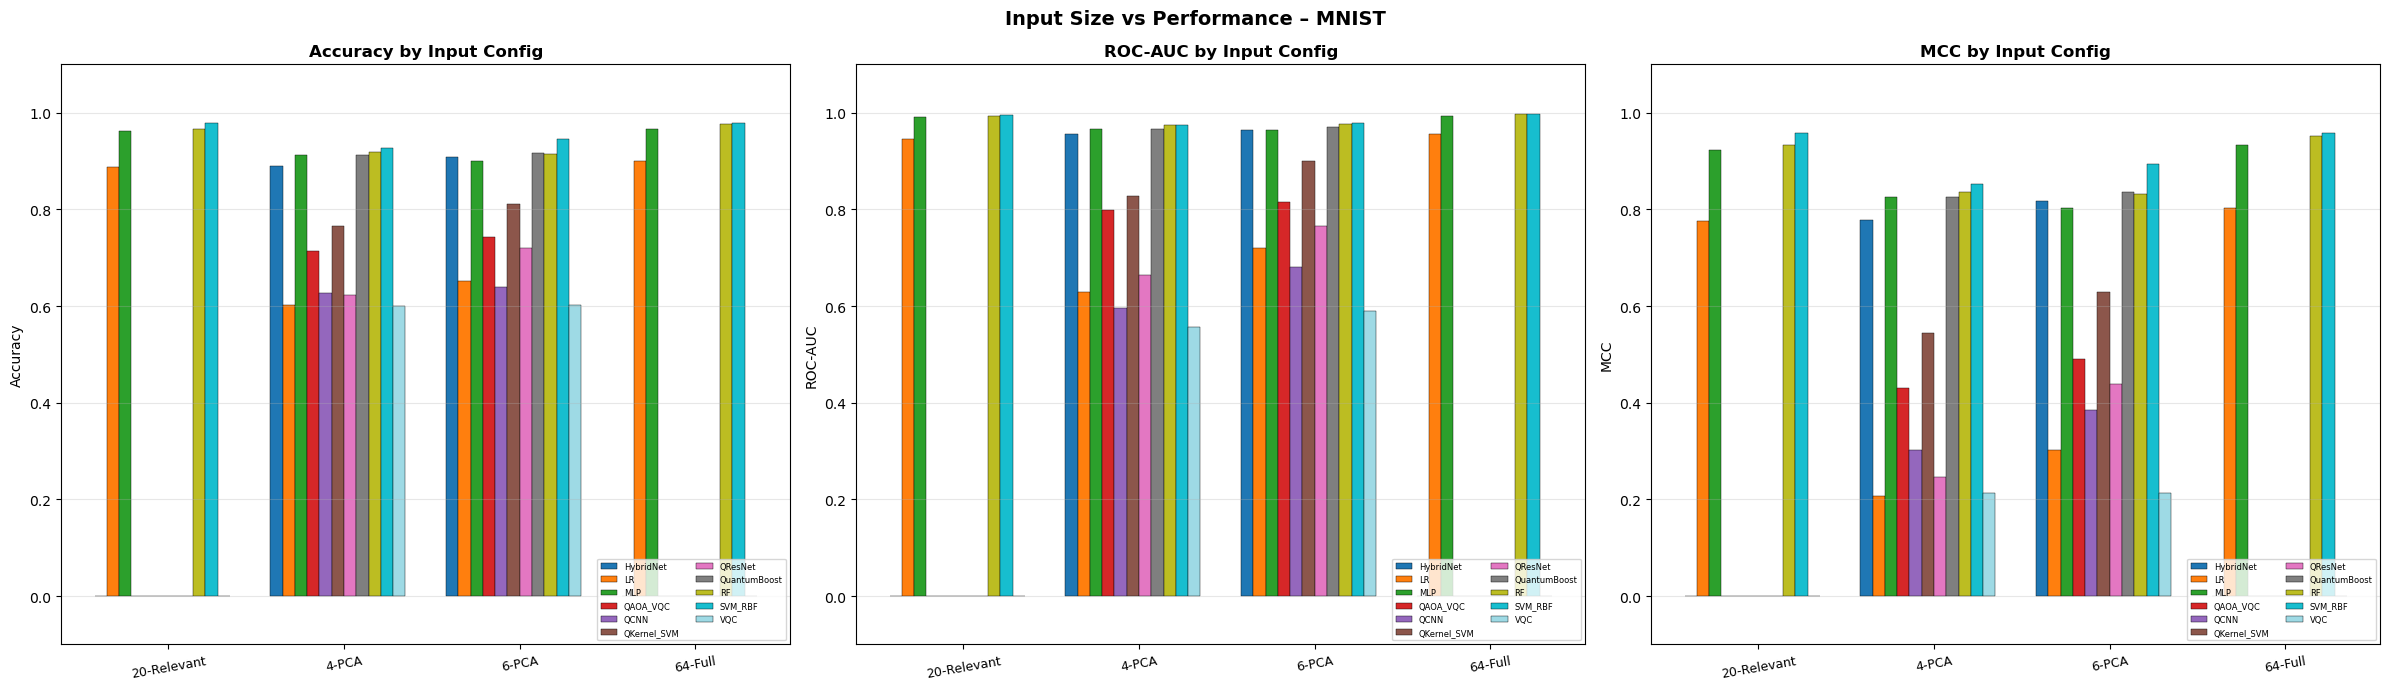

Input size comparison saved.


In [16]:
# ── Input size plots ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle("Input Size vs Performance – MNIST", fontsize=14, fontweight="bold")

for ax, metric, ylabel in zip(axes, ["acc","auc","mcc"], ["Accuracy","ROC-AUC","MCC"]):
    pivot = df_input.groupby(["config","model"])[metric].mean().unstack("model")
    x = np.arange(len(pivot))
    w = 0.07
    models = pivot.columns.tolist()
    colors = plt.cm.tab20(np.linspace(0,1,len(models)))
    for i,(m,col) in enumerate(zip(models, colors)):
        if m in pivot.columns:
            ax.bar(x + i*w, pivot[m].fillna(0), w, label=m, color=col, edgecolor="k", lw=0.3)
    ax.set_xticks(x + w*len(models)/2)
    ax.set_xticklabels(pivot.index, fontsize=9, rotation=10)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} by Input Config", fontweight="bold")
    ax.legend(fontsize=6, ncol=2, loc="lower right")
    ax.set_ylim(-0.1, 1.1)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(RES_DIR + "input_size_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Input size comparison saved.")


## 11) Main Benchmark (All Models × All Noise × 5 Seeds)

In [18]:
def run_main_benchmark(n_qubits=4, seeds=range(5), maxiter=80):
    """
    Full grid:
      - All 11 models
      - All 10 noise configs (quantum only for noise)
      - 5 seeds
      - 5-fold CV
    """
    X_np = X_df.values; y_np = y_s.values
    rows = []
    quantum_names = ["VQC","QCNN","QKernel_SVM","QAOA_VQC","HybridNet","QuantumBoost","QResNet"]

    for seed in seeds:
        set_seed(seed)
        # Classical: full features
        Xtr_f, Xte_f, ytr, yte = preprocess_dataset(
            X_np, y_np, n_features=X_np.shape[1], seed=seed, resample="smote", use_pca=False)
        # Quantum/hybrid: PCA to n_qubits
        Xtr_q, Xte_q, _, _ = preprocess_dataset(
            X_np, y_np, n_features=n_qubits, seed=seed, resample="smote", use_pca=True)

        models = get_all_models(n_qubits=n_qubits, seed=seed, maxiter=maxiter)

        for mname, model in models.items():
            Xtr = Xtr_q if mname in quantum_names else Xtr_f
            Xte = Xte_q if mname in quantum_names else Xte_f

            # No noise run
            try:
                res = evaluate_model(model, Xtr, ytr, Xte, yte)
                rows.append(dict(model=mname, seed=seed, noise="none", noise_param=0.0,
                                  **{k:v for k,v in res.items() if k not in ("cm","loss_curve")},
                                  loss_curve=res["loss_curve"]))
                print(f"  seed={seed} {mname:15s} acc={res['acc']:.3f} auc={res['auc']:.3f}")
            except Exception as e:
                print(f"[SKIP] {mname} seed={seed}: {str(e)[:30]}")

            # Noise runs (quantum + hybrid only)
            if mname in quantum_names:
                for nc in NOISE_CONFIGS[1:]:
                    try:
                        m2 = copy.deepcopy(model)
                        Xtr_n = inject_noise(Xtr, nc, seed=seed)
                        Xte_n = inject_noise(Xte, nc, seed=seed+100)
                        res_n = evaluate_model(m2, Xtr_n, ytr, Xte_n, yte, cv_folds=3)
                        rows.append(dict(model=mname, seed=seed,
                                          noise=nc.noise_type, noise_param=nc.noise_param,
                                          **{k:v for k,v in res_n.items() if k not in ("cm","loss_curve")},
                                          loss_curve=res_n["loss_curve"]))
                    except Exception as e:
                        pass

        print(f"Seed {seed} done.")

    return pd.DataFrame(rows)


print("Starting main benchmark (takes several minutes)...")
df_main = run_main_benchmark(n_qubits=4, seeds=range(5), maxiter=80)
print(f"\nTotal rows: {len(df_main)}")
print("\nNo-noise summary:")
print(df_main[df_main["noise"]=="none"].groupby("model")[["acc","auc","f1","mcc","cv_mean"]].mean().round(3))


Starting main benchmark (takes several minutes)...
  seed=0 LR              acc=0.875 auc=0.947
  seed=0 SVM_RBF         acc=0.975 auc=0.996
  seed=0 RF              acc=0.975 auc=0.993
  seed=0 MLP             acc=0.961 auc=0.991
  seed=0 VQC             acc=0.603 auc=0.517
  seed=0 QCNN            acc=0.644 auc=0.583
  seed=0 QKernel_SVM     acc=0.772 auc=0.821
  seed=0 QAOA_VQC        acc=0.711 auc=0.810
  seed=0 HybridNet       acc=0.881 auc=0.958
  seed=0 QuantumBoost    acc=0.908 auc=0.968
  seed=0 QResNet         acc=0.622 auc=0.646
Seed 0 done.
  seed=1 LR              acc=0.911 auc=0.958
  seed=1 SVM_RBF         acc=0.981 auc=0.998
  seed=1 RF              acc=0.972 auc=0.997
  seed=1 MLP             acc=0.967 auc=0.995
  seed=1 VQC             acc=0.608 auc=0.549
  seed=1 QCNN            acc=0.606 auc=0.590
  seed=1 QKernel_SVM     acc=0.769 auc=0.826
  seed=1 QAOA_VQC        acc=0.731 auc=0.815
  seed=1 HybridNet       acc=0.900 auc=0.956
  seed=1 QuantumBoost    acc=0.922 a

## 12) Multiple Accuracy Metrics & Comprehensive Visualizations

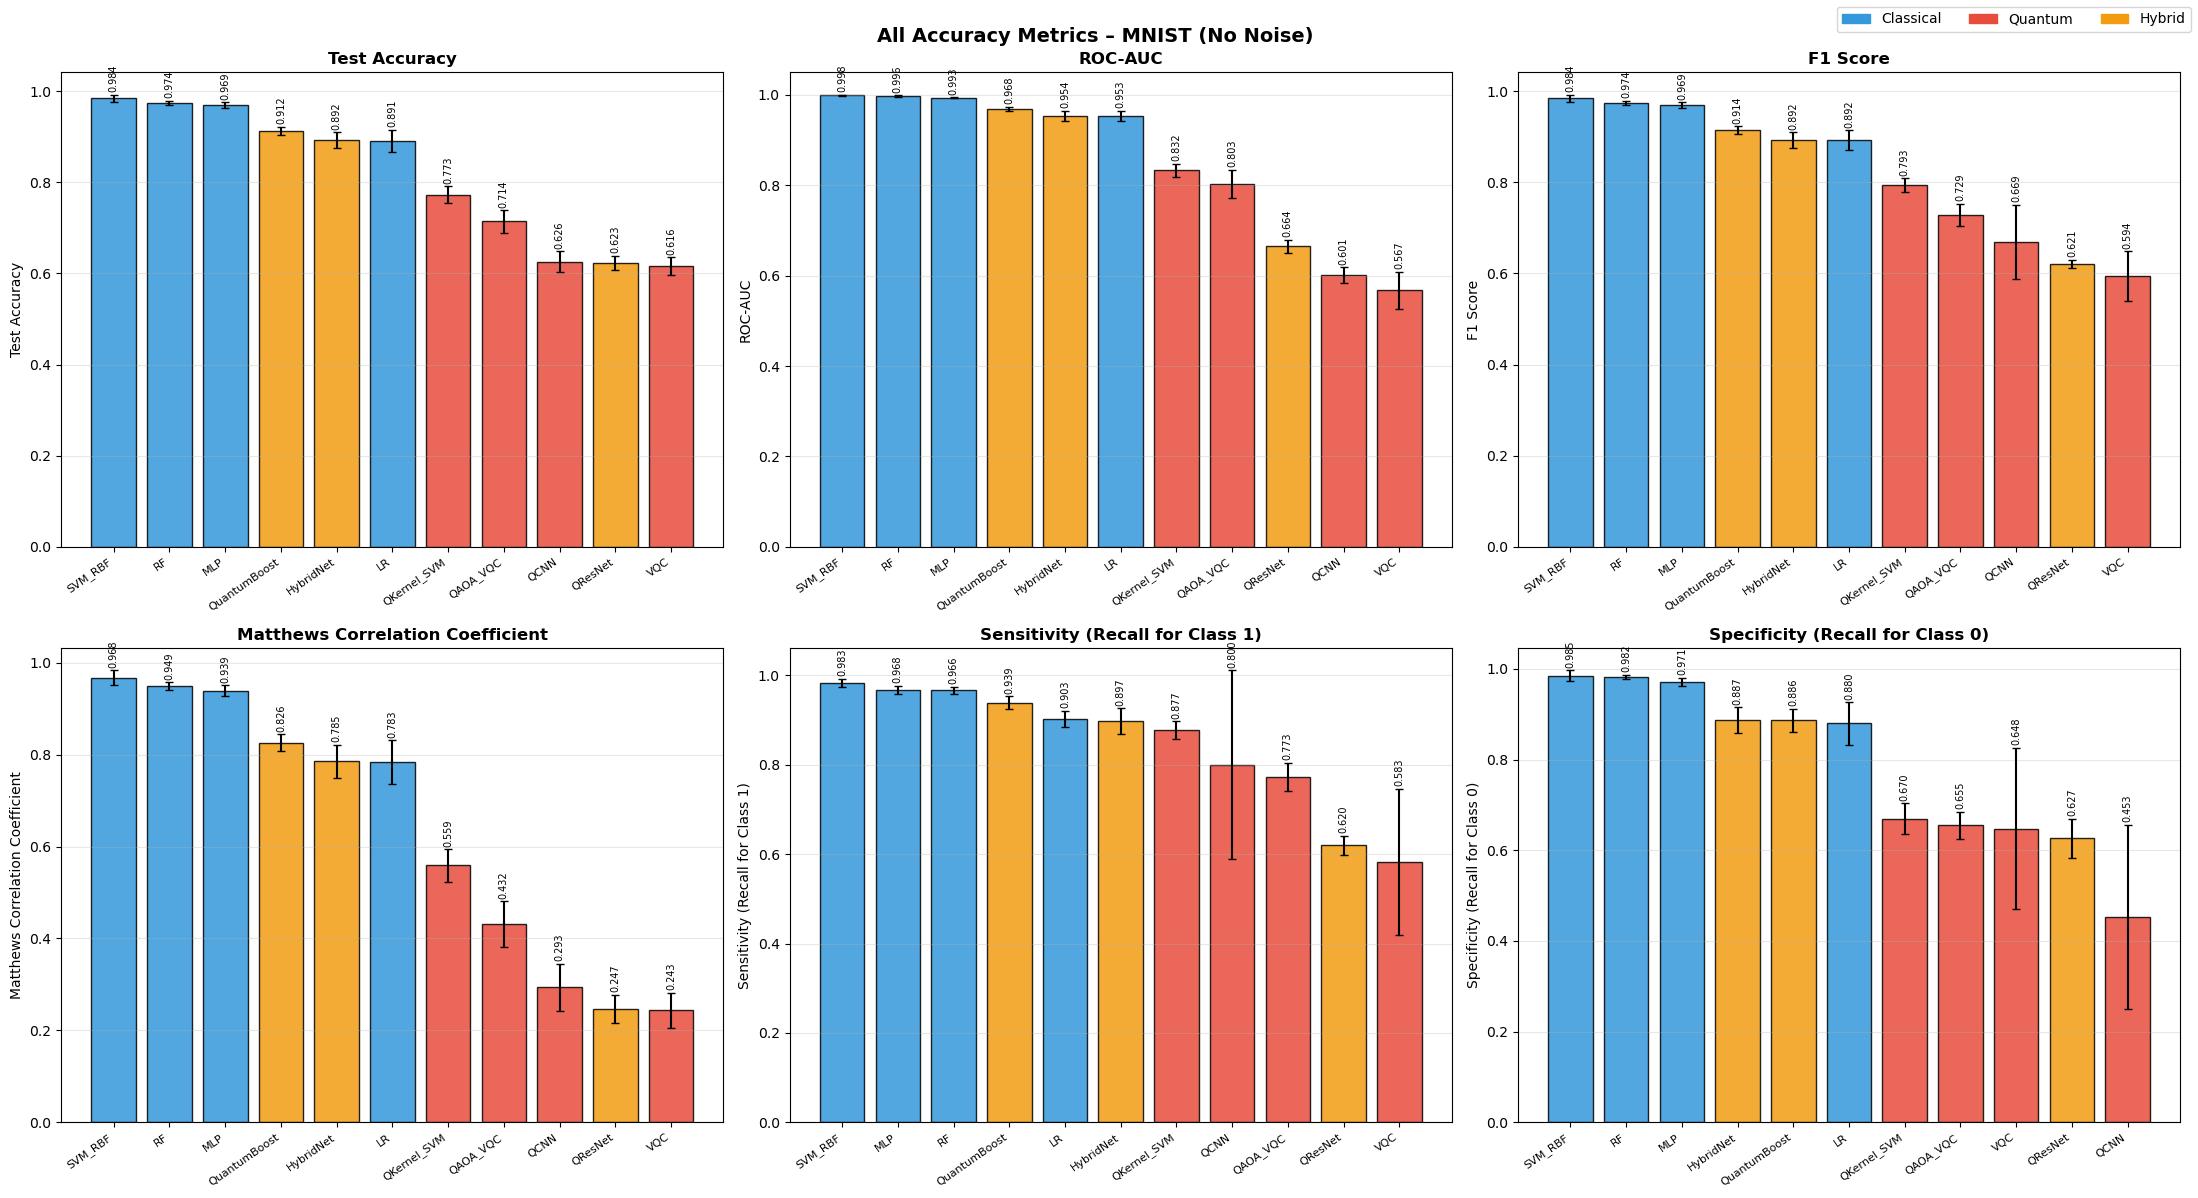

All accuracy metrics plot saved.


In [19]:
df_ideal = df_main[df_main["noise"]=="none"].copy()
order = df_ideal.groupby("model")["acc"].mean().sort_values(ascending=False).index

# ── Plot 1: All accuracy metrics overview ─────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle("All Accuracy Metrics – MNIST (No Noise)", fontsize=14, fontweight="bold")
axes = axes.flatten()

metrics_list = [
    ("acc",         "Test Accuracy"),
    ("auc",         "ROC-AUC"),
    ("f1",          "F1 Score"),
    ("mcc",         "Matthews Correlation Coefficient"),
    ("sensitivity", "Sensitivity (Recall for Class 1)"),
    ("specificity", "Specificity (Recall for Class 0)"),
]

cat_col = {"LR":"#3498db","SVM_RBF":"#3498db","RF":"#3498db","MLP":"#3498db",
           "VQC":"#e74c3c","QCNN":"#e74c3c","QKernel_SVM":"#e74c3c","QAOA_VQC":"#e74c3c",
           "HybridNet":"#f39c12","QuantumBoost":"#f39c12","QResNet":"#f39c12"}

for ax, (metric, label) in zip(axes, metrics_list):
    ord_m = df_ideal.groupby("model")[metric].mean().sort_values(ascending=False).index
    means = df_ideal.groupby("model")[metric].mean().loc[ord_m]
    stds  = df_ideal.groupby("model")[metric].std().loc[ord_m]
    cols  = [cat_col.get(m, "gray") for m in ord_m]
    bars  = ax.bar(range(len(ord_m)), means.values, yerr=stds.values,
                   color=cols, edgecolor="k", alpha=0.85, capsize=3)
    ax.set_xticks(range(len(ord_m)))
    ax.set_xticklabels(ord_m, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(label, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    for bar, v, s in zip(bars, means.values, stds.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.01,
                f"{v:.3f}", ha="center", fontsize=7, rotation=90)

legend_h = [mpatches.Patch(color="#3498db", label="Classical"),
            mpatches.Patch(color="#e74c3c", label="Quantum"),
            mpatches.Patch(color="#f39c12", label="Hybrid")]
fig.legend(handles=legend_h, fontsize=10, loc="upper right", ncol=3)

plt.tight_layout()
plt.savefig(RES_DIR + "all_accuracy_metrics.png", dpi=120, bbox_inches="tight")
plt.show()
print("All accuracy metrics plot saved.")


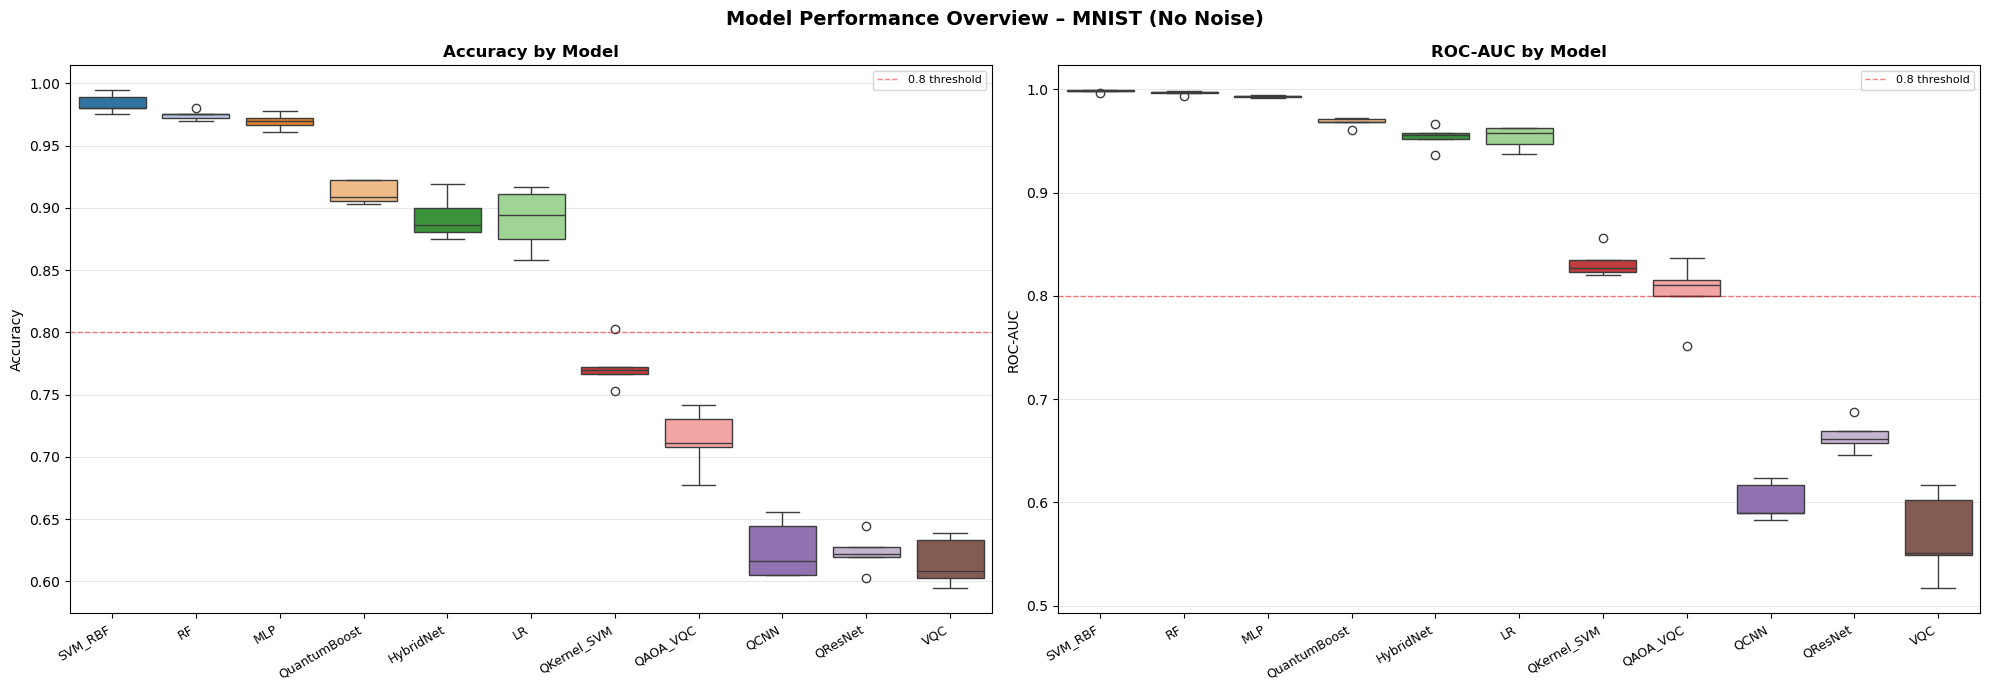

In [20]:
# ── Plot 2: Model Performance Boxplot ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("Model Performance Overview – MNIST (No Noise)", fontsize=14, fontweight="bold")

for ax, metric, label in zip(axes, ["acc","auc"], ["Accuracy","ROC-AUC"]):
    sns.boxplot(data=df_ideal, x="model", y=metric, order=order,
                palette="tab20", ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
    ax.set_title(f"{label} by Model", fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel(label)
    ax.axhline(0.8, color="red", ls="--", lw=1, alpha=0.5, label="0.8 threshold")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(RES_DIR + "benchmark_overview.png", dpi=120, bbox_inches="tight")
plt.show()


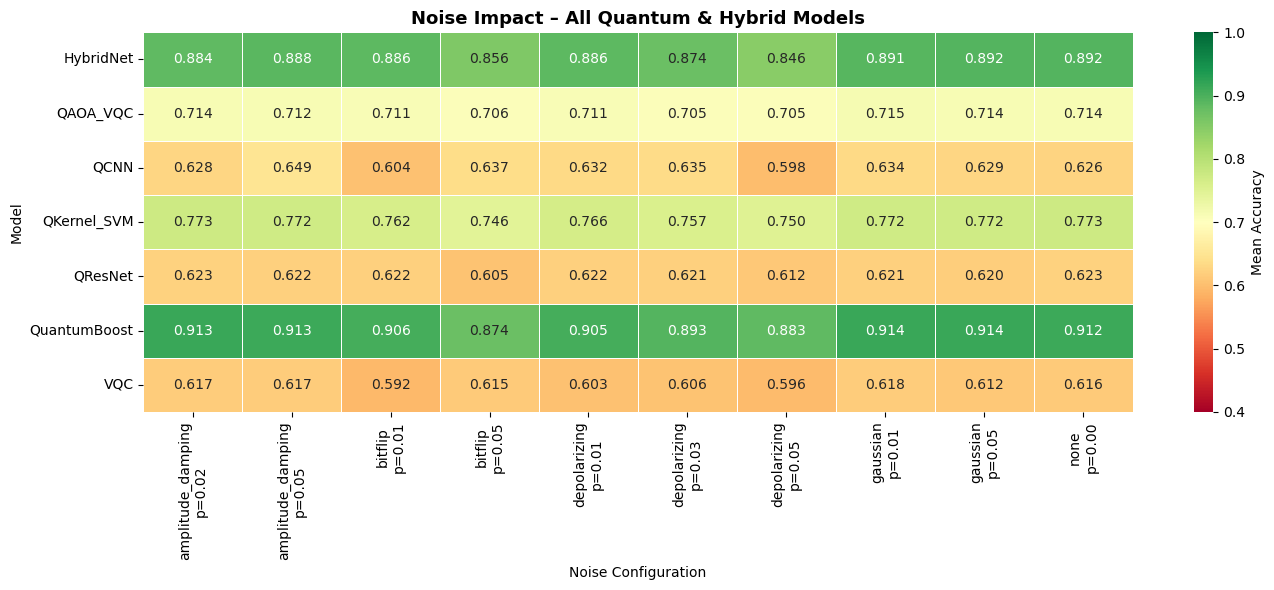

In [21]:
# ── Plot 3: Noise Robustness Heatmap ──────────────────
quantum_models = ["VQC","QCNN","QKernel_SVM","QAOA_VQC","HybridNet","QuantumBoost","QResNet"]
df_noise = df_main[df_main["model"].isin(quantum_models)].copy()
df_noise["noise_label"] = df_noise.apply(
    lambda r: f'{r["noise"]}\np={r["noise_param"]:.2f}', axis=1)

pivot_noise = df_noise.pivot_table(index="model", columns="noise_label",
                                    values="acc", aggfunc="mean")

fig, ax = plt.subplots(figsize=(max(14, len(pivot_noise.columns)*1.4), 6))
sns.heatmap(pivot_noise, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0.4, vmax=1.0, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Mean Accuracy"})
ax.set_title("Noise Impact – All Quantum & Hybrid Models", fontsize=13, fontweight="bold")
ax.set_xlabel("Noise Configuration"); ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig(RES_DIR + "noise_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


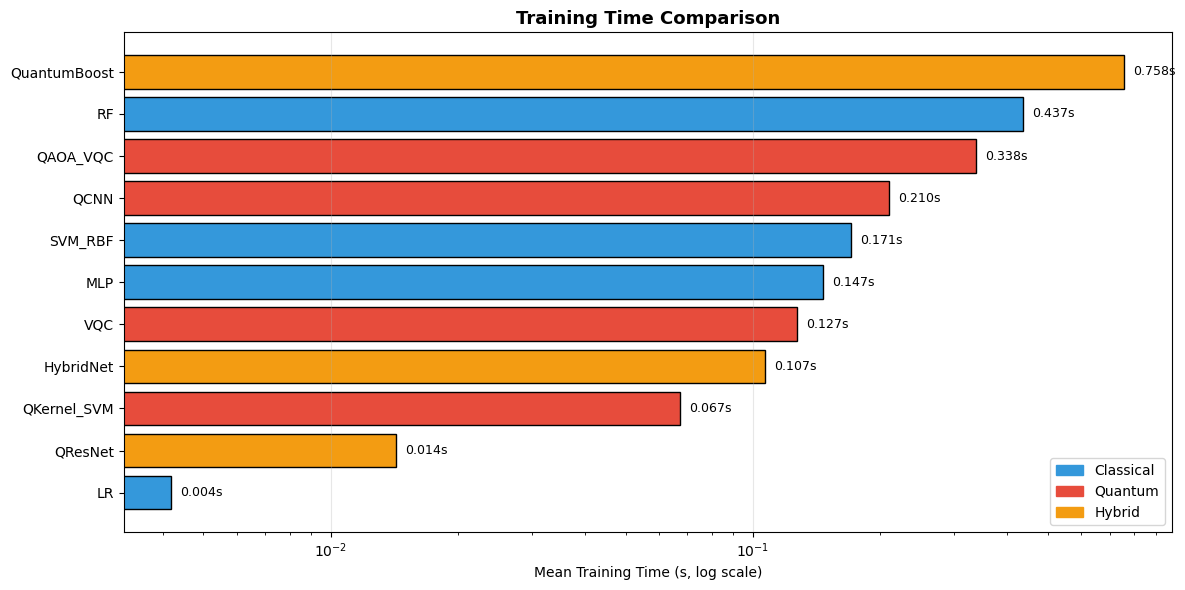

In [22]:
# ── Plot 4: Training Time Comparison ───────────────────
fig, ax = plt.subplots(figsize=(12, 6))
time_order = df_ideal.groupby("model")["train_time"].mean().sort_values()
colors_t = ["#e74c3c" if m in ["VQC","QCNN","QKernel_SVM","QAOA_VQC"] else
            "#f39c12" if m in ["HybridNet","QuantumBoost","QResNet"] else
            "#3498db" for m in time_order.index]
bars = ax.barh(time_order.index, time_order.values, color=colors_t, edgecolor="k")
ax.set_xscale("log")
ax.set_xlabel("Mean Training Time (s, log scale)")
ax.set_title("Training Time Comparison", fontsize=13, fontweight="bold")
for bar, val in zip(bars, time_order.values):
    ax.text(val*1.05, bar.get_y()+bar.get_height()/2, f"{val:.3f}s", va="center", fontsize=9)
legend_patches = [mpatches.Patch(color="#3498db", label="Classical"),
                  mpatches.Patch(color="#e74c3c", label="Quantum"),
                  mpatches.Patch(color="#f39c12", label="Hybrid")]
ax.legend(handles=legend_patches); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(RES_DIR + "training_time.png", dpi=120, bbox_inches="tight")
plt.show()


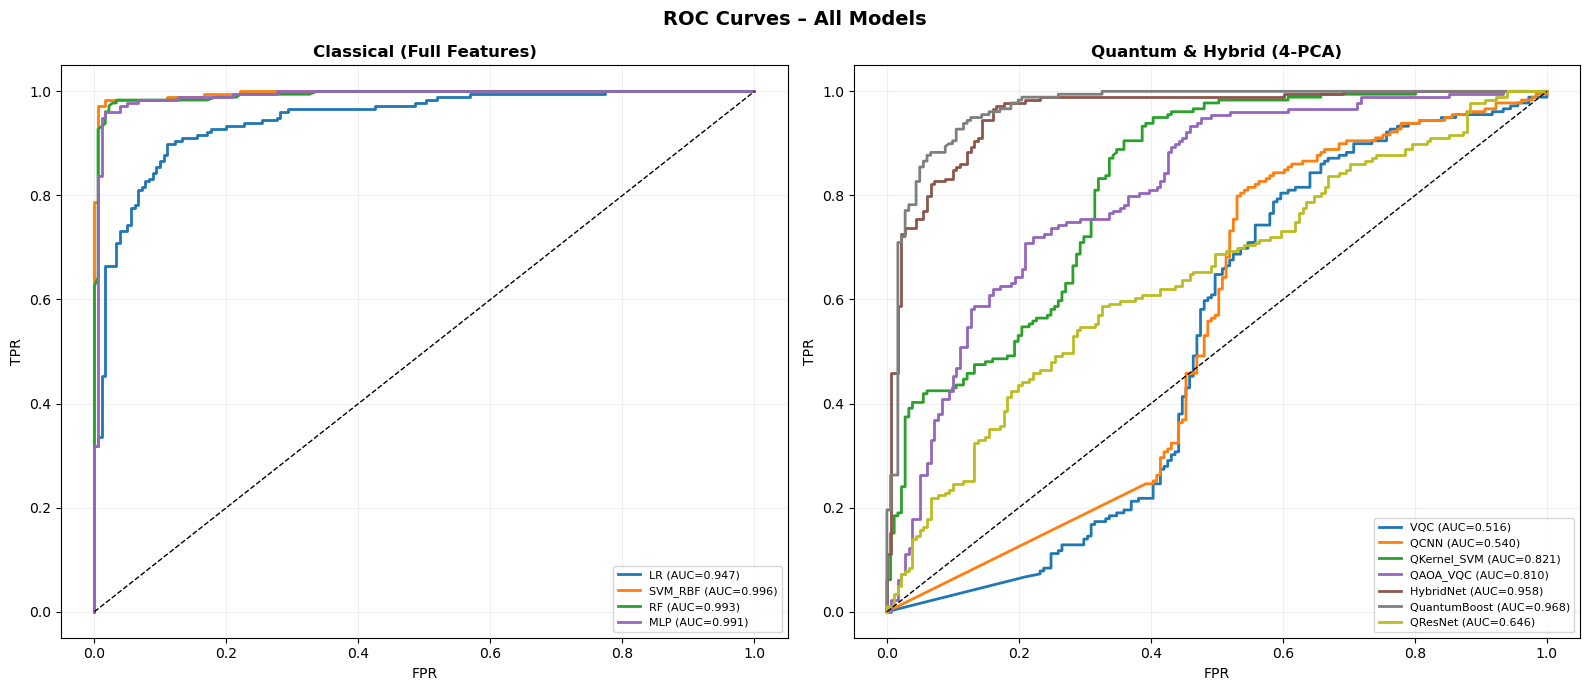

In [23]:
# ── Plot 5: ROC Curves ────────────────────────────────
X_np = X_df.values; y_np = y_s.values
Xtr_r, Xte_r, ytr_r, yte_r = preprocess_dataset(X_np, y_np, n_features=4, seed=0, use_pca=True)
Xtr_f2, Xte_f2, ytr_f2, yte_f2 = preprocess_dataset(X_np, y_np, n_features=X_np.shape[1], seed=0, use_pca=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("ROC Curves – All Models", fontsize=14, fontweight="bold")

model_sets = [
    ("Classical (Full Features)", ["LR","SVM_RBF","RF","MLP"], Xtr_f2, Xte_f2, ytr_f2, yte_f2),
    ("Quantum & Hybrid (4-PCA)",  ["VQC","QCNN","QKernel_SVM","QAOA_VQC",
                                    "HybridNet","QuantumBoost","QResNet"],
     Xtr_r, Xte_r, ytr_r, yte_r),
]

colors_roc = plt.cm.tab10(np.linspace(0,1,8))

for ax, (title, mnames, Xtr_, Xte_, ytr_, yte_) in zip(axes, model_sets):
    all_m = get_all_models(n_qubits=4, seed=0, maxiter=60)
    for mname, col in zip(mnames, colors_roc):
        if mname not in all_m: continue
        m = copy.deepcopy(all_m[mname])
        try:
            m.fit(Xtr_, ytr_)
            proba = m.predict_proba(Xte_)[:,1]
            fpr, tpr, _ = roc_curve(yte_, proba)
            auc = roc_auc_score(yte_, proba)
            ax.plot(fpr, tpr, lw=2, color=col, label=f"{mname} (AUC={auc:.3f})")
        except Exception as e:
            pass
    ax.plot([0,1],[0,1],"k--",lw=1)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(title, fontweight="bold"); ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(RES_DIR + "roc_curves.png", dpi=120, bbox_inches="tight")
plt.show()


## 13) Ablation Study

In [24]:
def run_ablation(seeds=range(3)):
    """Ablation: vary qubits, reps, shots for VQC and QCNN."""
    X_np = X_df.values; y_np = y_s.values
    rows = []
    for n_q in [2, 4, 6, 8]:
        for reps in [1, 2, 3]:
            for shots in [64, 256, 1024]:
                for seed in seeds:
                    set_seed(seed)
                    Xtr, Xte, ytr, yte = preprocess_dataset(
                        X_np, y_np, n_features=n_q, seed=seed, use_pca=True)
                    for mname, cls_ in [("VQC", NumpyVQC), ("QCNN", NumpyQCNN)]:
                        try:
                            m = cls_(n_qubits=n_q, reps=reps, shots=shots, seed=seed, maxiter=60)
                            res = evaluate_model(m, Xtr, ytr, Xte, yte, cv_folds=3)
                            rows.append(dict(model=mname, n_qubits=n_q, reps=reps,
                                             shots=shots, seed=seed,
                                             acc=res["acc"], auc=res["auc"], mcc=res["mcc"]))
                        except:
                            pass
    return pd.DataFrame(rows)


print("Running ablation study...")
df_ablation = run_ablation(seeds=range(3))
print(f"Ablation rows: {len(df_ablation)}")


Running ablation study...
Ablation rows: 216


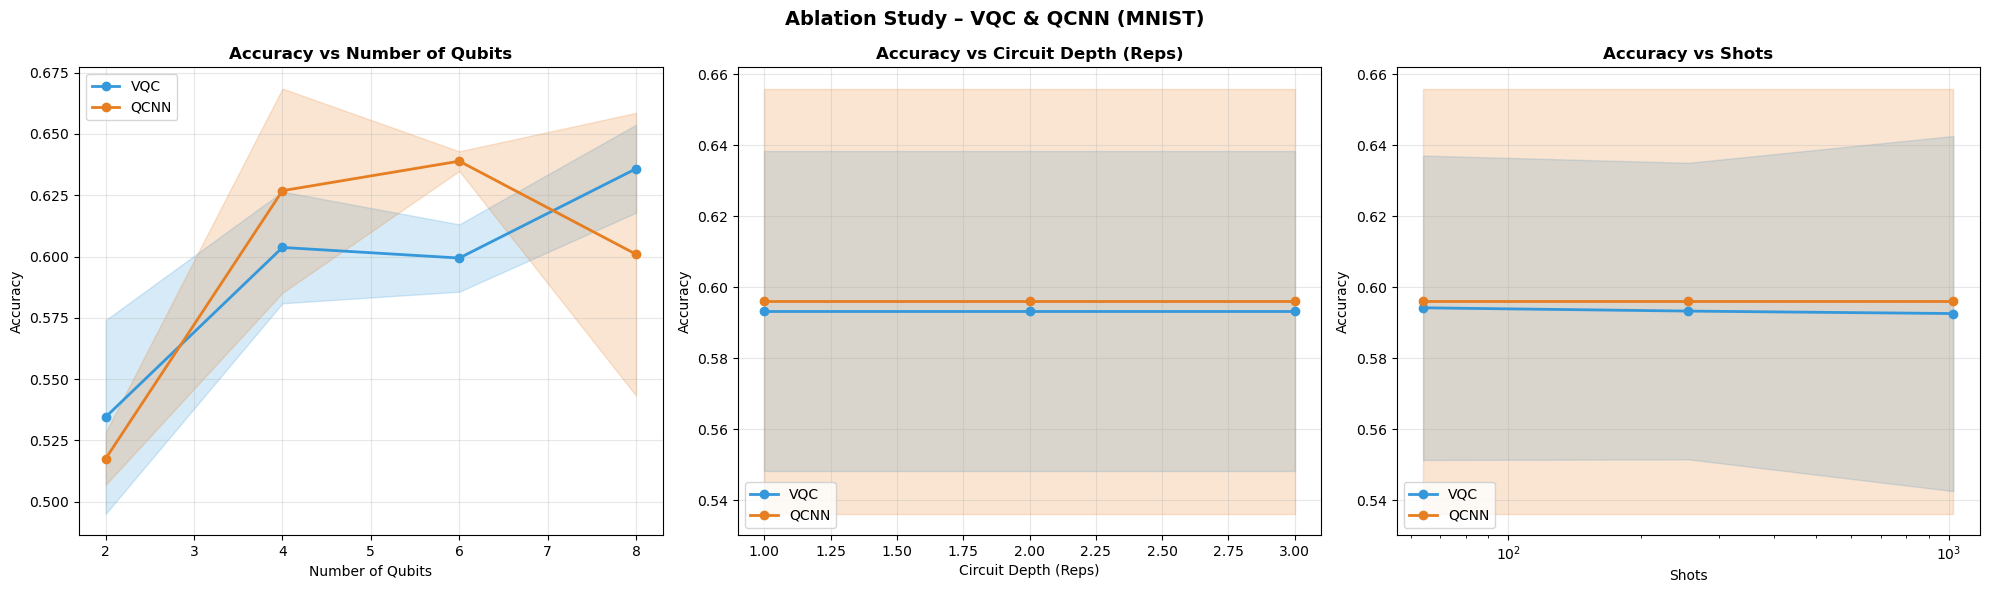

In [25]:
# ── Ablation Plots ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Ablation Study – VQC & QCNN (MNIST)", fontsize=14, fontweight="bold")

for ax, var, xlabel in zip(axes,
    ["n_qubits","reps","shots"], ["Number of Qubits","Circuit Depth (Reps)","Shots"]):
    for mname, col in [("VQC","#3498db"), ("QCNN","#e67e22")]:
        sub = df_ablation[df_ablation["model"]==mname].groupby(var)["acc"]
        if sub.ngroups == 0: continue
        mean_ = sub.mean(); std_ = sub.std().fillna(0)
        ax.plot(mean_.index, mean_.values, "o-", color=col, lw=2, label=mname)
        ax.fill_between(mean_.index, mean_-std_, mean_+std_, alpha=0.2, color=col)
    ax.set_xlabel(xlabel); ax.set_ylabel("Accuracy")
    ax.set_title(f"Accuracy vs {xlabel}", fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)
    if var == "shots": ax.set_xscale("log")

plt.tight_layout()
plt.savefig(RES_DIR + "ablation_study.png", dpi=120, bbox_inches="tight")
plt.show()


## 14) Statistical Tests

In [26]:
def run_statistical_tests(df: pd.DataFrame):
    df_no_noise = df[df["noise"]=="none"].copy()
    models = df_no_noise["model"].unique()

    cl_models = ["LR","SVM_RBF","RF","MLP"]
    best_cl = df_no_noise[df_no_noise["model"].isin(cl_models)].groupby("model")["cv_mean"].mean().idxmax()
    cl_accs = df_no_noise[df_no_noise["model"]==best_cl].groupby("seed")["cv_mean"].mean().values

    print(f"Reference classical: {best_cl} (mean CV={cl_accs.mean():.4f})")
    print("="*75)
    print(f'{"Model":18s} {"Mean":>7} {"Std":>7} {"t-stat":>8} {"p(t)":>8} '
          f'{"Cohen d":>8} {"Sig":>5}')
    print("-"*75)

    rows = []
    for mname in models:
        if mname == best_cl: continue
        m_accs = df_no_noise[df_no_noise["model"]==mname].groupby("seed")["cv_mean"].mean().values
        n = min(len(cl_accs), len(m_accs))
        if n < 2: continue
        a = cl_accs[:n]; b = m_accs[:n]
        try:
            t_s, p_t = ttest_rel(a, b)
        except:
            t_s, p_t = float("nan"), float("nan")
        diff = b - a
        d_ = diff.mean() / (diff.std()+1e-10)
        sig = "***" if p_t<0.001 else "**" if p_t<0.01 else "*" if p_t<0.05 else "ns"
        print(f"{mname:18s} {b.mean():7.4f} {b.std():7.4f} {t_s:8.3f} {p_t:8.4f} "
              f"{d_:8.3f} {sig:>5}")
        rows.append(dict(model=mname, mean=b.mean(), std=b.std(),
                          t_stat=t_s, p_t=p_t,
                          cohen_d=d_, significant=sig))

    return pd.DataFrame(rows)


df_stats = run_statistical_tests(df_main)


Reference classical: SVM_RBF (mean CV=0.9817)
Model                 Mean     Std   t-stat     p(t)  Cohen d   Sig
---------------------------------------------------------------------------
LR                  0.8978  0.0040   36.731   0.0000  -18.366   ***
RF                  0.9764  0.0003    6.892   0.0023   -3.446    **
MLP                 0.9672  0.0061    5.858   0.0042   -2.929    **
VQC                 0.6250  0.0083   86.099   0.0000  -43.049   ***
QCNN                0.6547  0.0231   28.436   0.0000  -14.218   ***
QKernel_SVM         0.7827  0.0028  104.542   0.0000  -52.271   ***
QAOA_VQC            0.7114  0.0076   64.675   0.0000  -32.338   ***
HybridNet           0.8924  0.0086   19.597   0.0000   -9.799   ***
QuantumBoost        0.9112  0.0044   26.135   0.0000  -13.067   ***
QResNet             0.6113  0.0044  151.893   0.0000  -75.946   ***


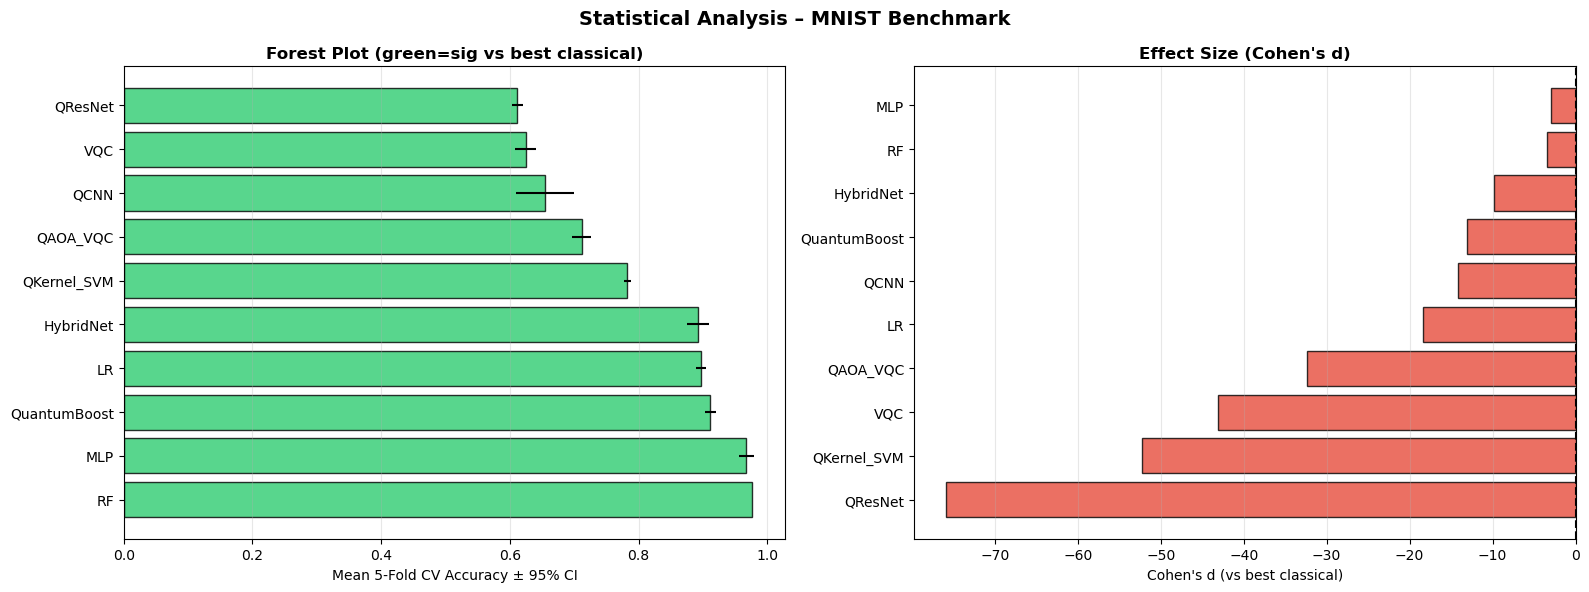

In [29]:
# ── Statistical plot ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Statistical Analysis – MNIST Benchmark", fontsize=14, fontweight="bold")

if not df_stats.empty:
    order_s = df_stats.sort_values("mean", ascending=False)
    colors_s = ["#2ecc71" if p<0.05 else "#e74c3c" for p in order_s["p_t"]]
    axes[0].barh(range(len(order_s)), order_s["mean"],
                 xerr=1.96*order_s["std"], color=colors_s, edgecolor="k", alpha=0.8)
    axes[0].set_yticks(range(len(order_s)))
    axes[0].set_yticklabels(order_s["model"])
    axes[0].set_xlabel("Mean 5-Fold CV Accuracy ± 95% CI")
    axes[0].set_title("Forest Plot (green=sig vs best classical)", fontweight="bold")
    axes[0].grid(axis="x", alpha=0.3)

    order_d = df_stats.sort_values("cohen_d", ascending=True)
    colors_d = ["#2ecc71" if d>0 else "#e74c3c" for d in order_d["cohen_d"]]
    axes[1].barh(range(len(order_d)), order_d["cohen_d"], color=colors_d, edgecolor="k", alpha=0.8)
    axes[1].set_yticks(range(len(order_d)))
    axes[1].set_yticklabels(order_d["model"])
    axes[1].axvline(0, color="black", lw=1.5, ls="--")
    axes[1].set_xlabel("Cohen's d (vs best classical)")
    axes[1].set_title("Effect Size (Cohen's d)", fontweight="bold")
    axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(RES_DIR + "statistical_tests.png", dpi=120, bbox_inches="tight")
plt.show()


## 15) Extended PCA Variants Experiment

In [31]:
def run_pca_variants_experiment(seeds=range(3), maxiter=60):
    X_np = X_df.values; y_np = y_s.values
    quantum_names = ["VQC","QCNN","QKernel_SVM","QAOA_VQC","HybridNet","QuantumBoost","QResNet"]

    pca_configs = [
        ("PCA-2",  2,  True),
        ("PCA-4",  4,  True),
        ("PCA-6",  6,  True),
        ("PCA-8",  8,  True),
        ("Full-64", 64, False),
    ]

    rows = []
    for cfg_label, n_comp, use_pca in pca_configs:
        print(f"\n── PCA Config: {cfg_label} ──")
        for seed in seeds:
            set_seed(seed)
            Xtr, Xte, ytr, yte = preprocess_dataset(
                X_np, y_np, n_features=n_comp, seed=seed,
                resample="smote", use_pca=use_pca)
            n_q = min(n_comp, 8)
            models = get_all_models(n_qubits=n_q, seed=seed, maxiter=maxiter)
            if not use_pca:
                models = {k:v for k,v in models.items() if k not in quantum_names}
            elif n_comp > 8:
                models = {k:v for k,v in models.items() if k not in quantum_names}

            for mname, model in models.items():
                try:
                    res = evaluate_model(copy.deepcopy(model), Xtr, ytr, Xte, yte, cv_folds=5)
                    rows.append(dict(pca_config=cfg_label, n_components=n_comp,
                                     model=mname, seed=seed,
                                     acc=res["acc"], auc=res["auc"], f1=res["f1"],
                                     mcc=res["mcc"], cv_mean=res["cv_mean"],
                                     cv_std=res["cv_std"], train_time=res["train_time"]))
                    print(f"  {mname:15s} acc={res['acc']:.3f} auc={res['auc']:.3f}")
                except Exception as e:
                    pass

    return pd.DataFrame(rows)


print("Starting Extended PCA Variants Experiment...")
df_pca_variants = run_pca_variants_experiment(seeds=range(3), maxiter=60)
print(f"\nDone. {len(df_pca_variants)} result rows.")


Starting Extended PCA Variants Experiment...

── PCA Config: PCA-2 ──
  LR              acc=0.639 auc=0.652
  SVM_RBF         acc=0.794 auc=0.871
  RF              acc=0.800 auc=0.870
  MLP             acc=0.756 auc=0.845
  VQC             acc=0.508 auc=0.517
  QCNN            acc=0.525 auc=0.552
  QKernel_SVM     acc=0.708 auc=0.785
  QAOA_VQC        acc=0.686 auc=0.755
  HybridNet       acc=0.728 auc=0.821
  QuantumBoost    acc=0.811 auc=0.884
  QResNet         acc=0.639 auc=0.652
  LR              acc=0.633 auc=0.642
  SVM_RBF         acc=0.817 auc=0.894
  RF              acc=0.811 auc=0.905
  MLP             acc=0.781 auc=0.864
  VQC             acc=0.589 auc=0.591
  QCNN            acc=0.503 auc=0.494
  QKernel_SVM     acc=0.711 auc=0.793
  QAOA_VQC        acc=0.689 auc=0.777
  HybridNet       acc=0.714 auc=0.792
  QuantumBoost    acc=0.825 auc=0.906
  QResNet         acc=0.656 auc=0.656
  LR              acc=0.611 auc=0.616
  SVM_RBF         acc=0.772 auc=0.831
  RF              

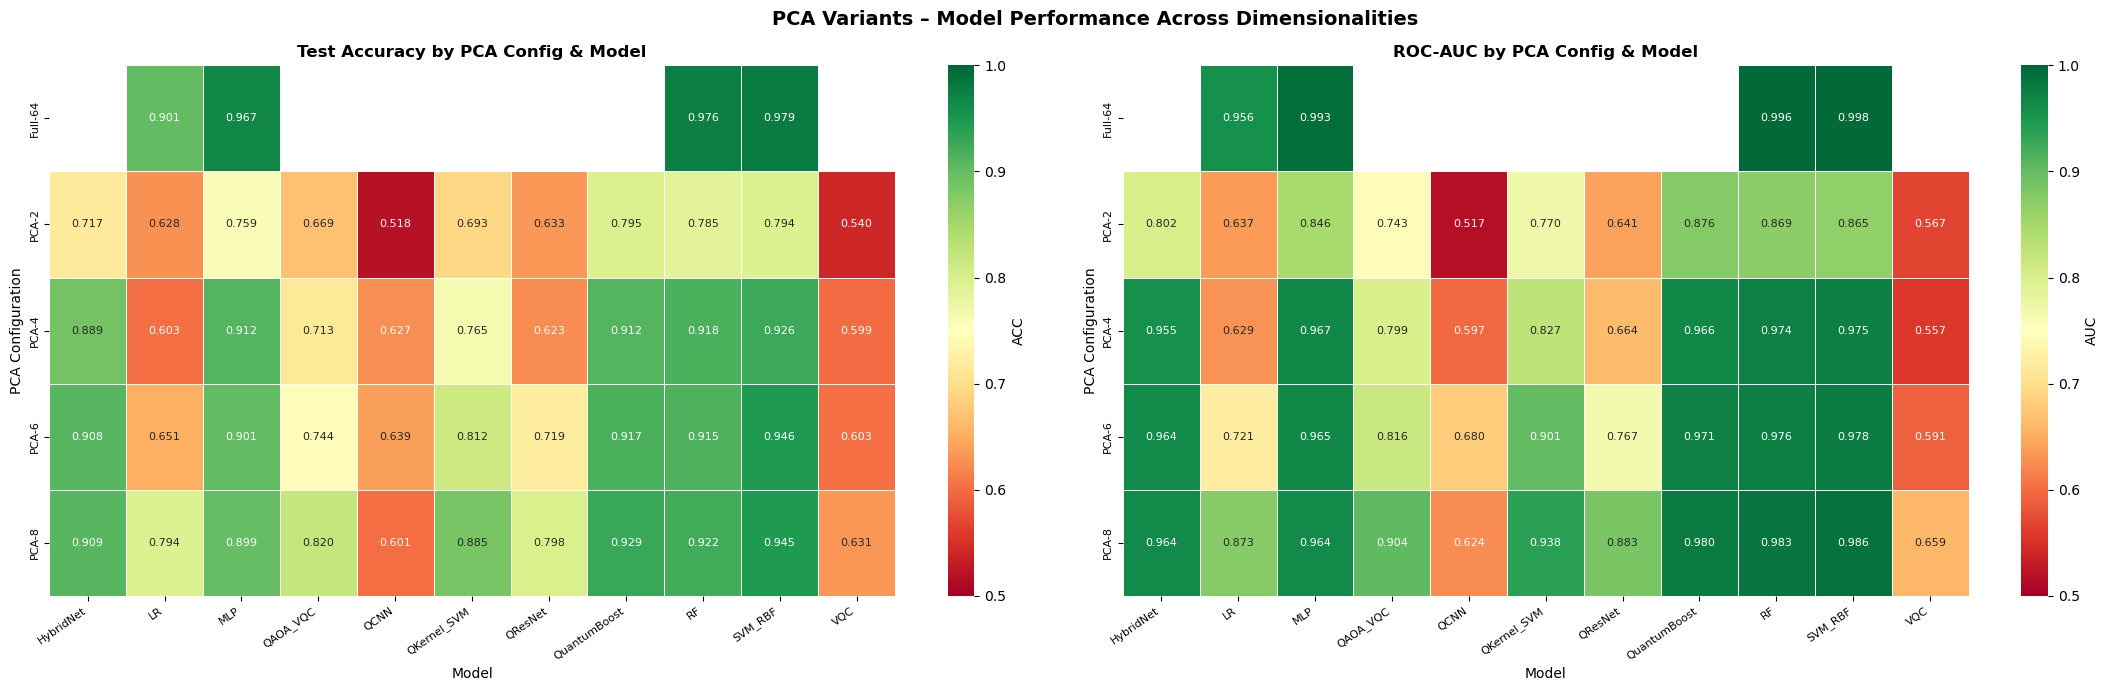

In [32]:
# ── PCA Variants Plots ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 7))
fig.suptitle("PCA Variants – Model Performance Across Dimensionalities", fontsize=14, fontweight="bold")

for ax, metric, title in zip(axes, ["acc","auc"], ["Test Accuracy","ROC-AUC"]):
    pivot = df_pca_variants.groupby(["pca_config","model"])[metric].mean().unstack("model")
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn",
                vmin=0.5, vmax=1.0, linewidths=0.5, ax=ax,
                cbar_kws={"label": metric.upper()}, annot_kws={"size":8})
    ax.set_title(f"{title} by PCA Config & Model", fontweight="bold")
    ax.set_xlabel("Model"); ax.set_ylabel("PCA Configuration")
    ax.tick_params(labelsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")

plt.tight_layout()
plt.savefig(RES_DIR + "pca_variants_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


## 16) Final Results & Summary Dashboard

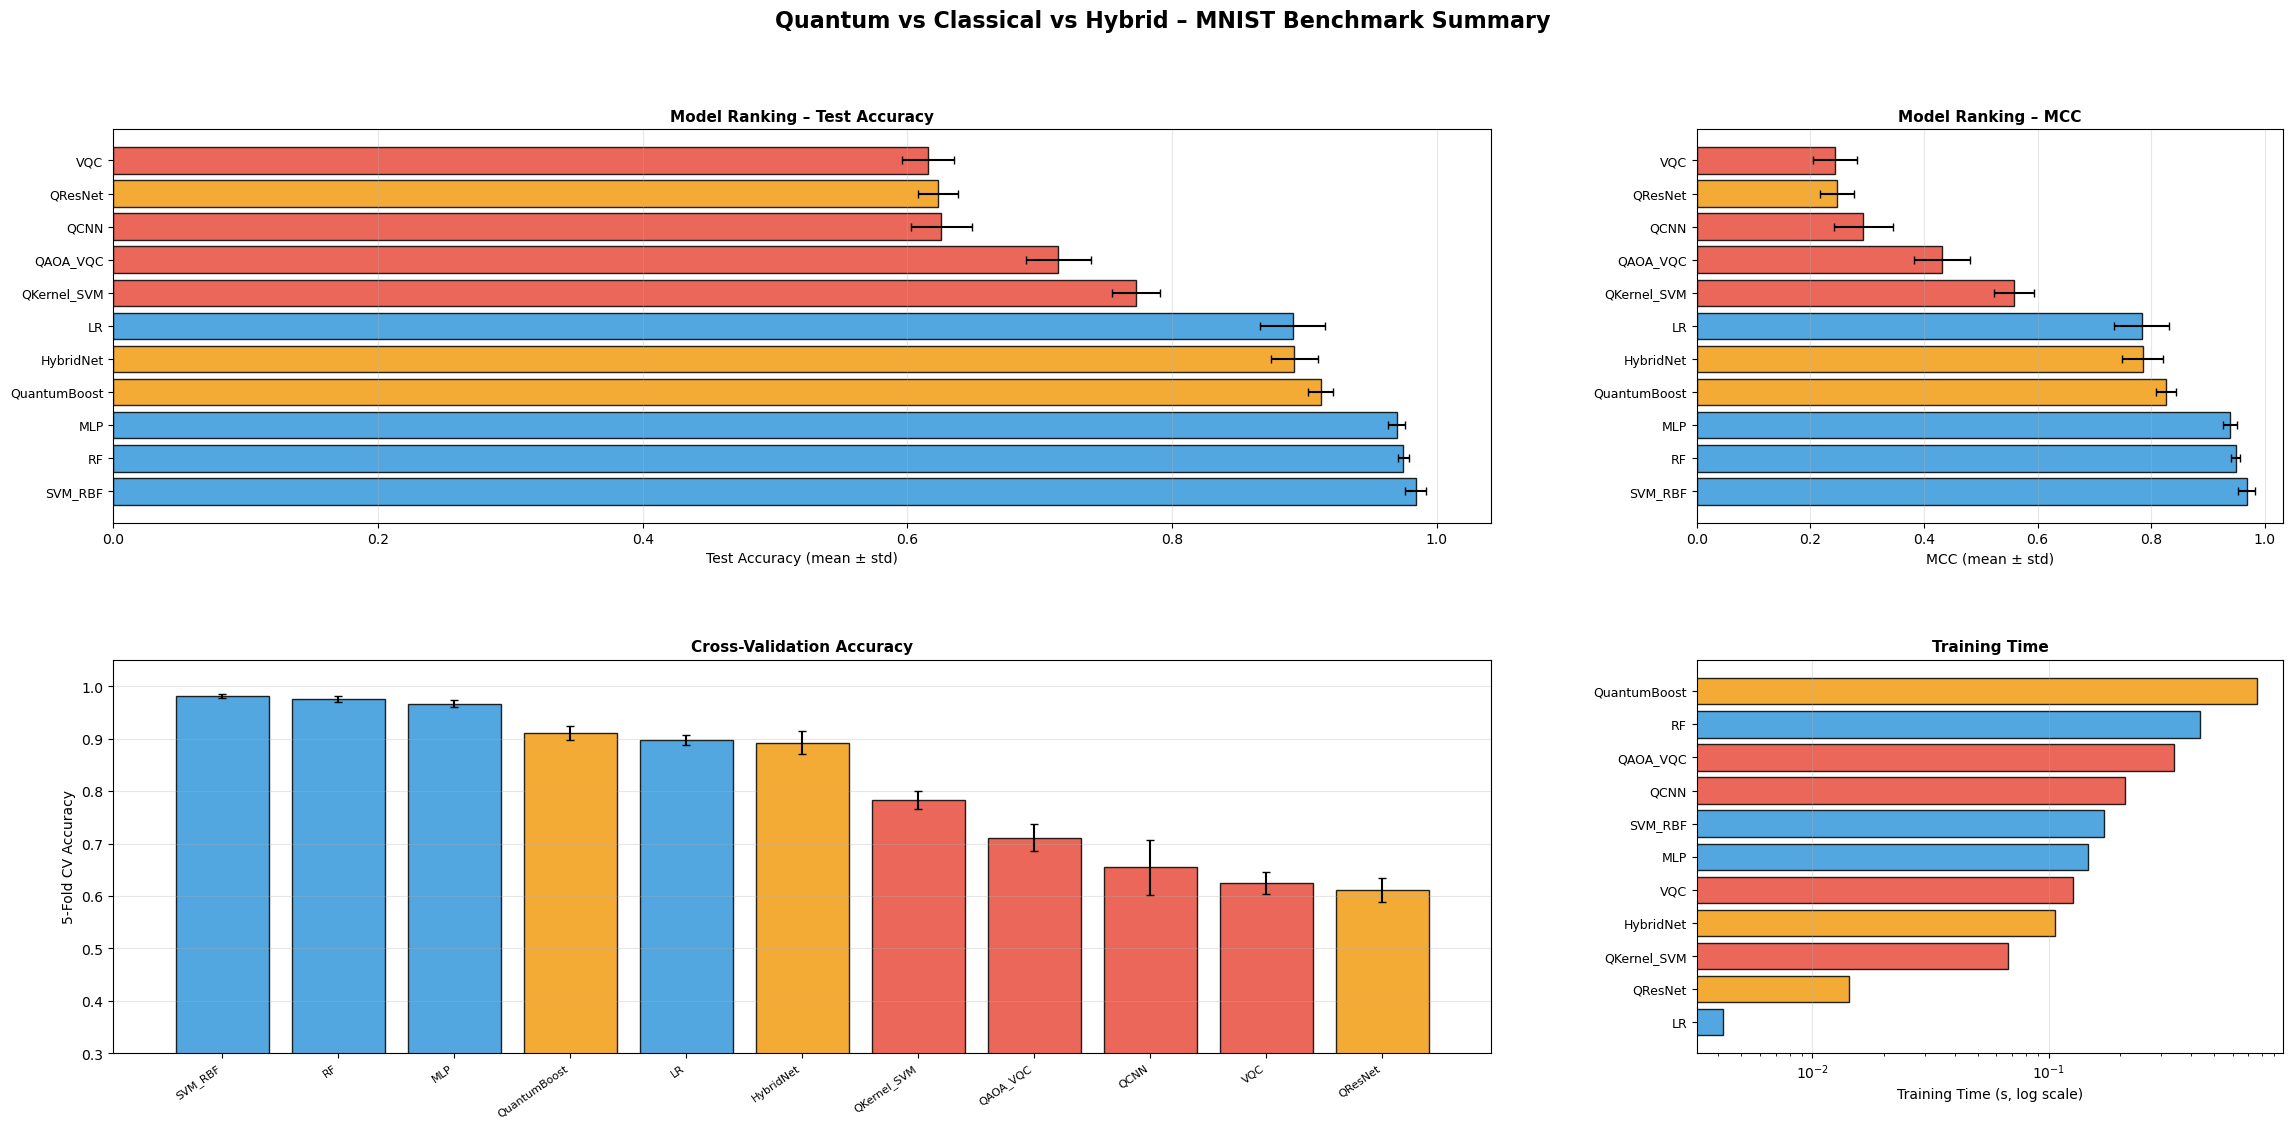

Saved: final_dashboard.png


In [33]:
# ── Final Summary Dashboard ───────────────────────────
def plot_final_dashboard(df_main):
    fig = plt.figure(figsize=(28, 12))
    gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)

    df_no = df_main[df_main["noise"]=="none"]
    order = df_no.groupby("model")["acc"].mean().sort_values(ascending=False).index

    cat_col = {"LR":"#3498db","SVM_RBF":"#3498db","RF":"#3498db","MLP":"#3498db",
               "VQC":"#e74c3c","QCNN":"#e74c3c","QKernel_SVM":"#e74c3c","QAOA_VQC":"#e74c3c",
               "HybridNet":"#f39c12","QuantumBoost":"#f39c12","QResNet":"#f39c12"}

    # 1) Accuracy ranking
    ax1 = fig.add_subplot(gs[0,:2])
    means = df_no.groupby("model")["acc"].mean().loc[order]
    stds = df_no.groupby("model")["acc"].std().loc[order]
    cols = [cat_col.get(m,"gray") for m in order]
    ax1.barh(range(len(order)), means.values, xerr=stds.values,
             color=cols, edgecolor="k", alpha=0.85, capsize=3)
    ax1.set_yticks(range(len(order)))
    ax1.set_yticklabels(order, fontsize=9)
    ax1.set_xlabel("Test Accuracy (mean ± std)")
    ax1.set_title("Model Ranking – Test Accuracy", fontweight="bold", fontsize=11)
    ax1.grid(axis="x", alpha=0.3)

    # 2) MCC ranking
    ax2 = fig.add_subplot(gs[0,2:])
    mcc_m = df_no.groupby("model")["mcc"].mean().sort_values(ascending=False)
    mcc_s = df_no.groupby("model")["mcc"].std().loc[mcc_m.index]
    mcc_cols = [cat_col.get(m,"gray") for m in mcc_m.index]
    ax2.barh(range(len(mcc_m)), mcc_m.values, xerr=mcc_s.values,
             color=mcc_cols, edgecolor="k", alpha=0.85, capsize=3)
    ax2.set_yticks(range(len(mcc_m)))
    ax2.set_yticklabels(mcc_m.index, fontsize=9)
    ax2.set_xlabel("MCC (mean ± std)")
    ax2.set_title("Model Ranking – MCC", fontweight="bold", fontsize=11)
    ax2.grid(axis="x", alpha=0.3)

    # 3) CV comparison
    ax3 = fig.add_subplot(gs[1,:2])
    cv_m = df_no.groupby("model")["cv_mean"].mean().sort_values(ascending=False)
    cv_s = df_no.groupby("model")["cv_std"].mean().loc[cv_m.index]
    ax3.bar(range(len(cv_m)), cv_m.values, yerr=cv_s.values,
            color=[cat_col.get(m,"gray") for m in cv_m.index],
            edgecolor="k", alpha=0.85, capsize=3)
    ax3.set_xticks(range(len(cv_m)))
    ax3.set_xticklabels(cv_m.index, rotation=35, ha="right", fontsize=8)
    ax3.set_ylabel("5-Fold CV Accuracy")
    ax3.set_title("Cross-Validation Accuracy", fontweight="bold", fontsize=11)
    ax3.set_ylim(0.3,1.05); ax3.grid(axis="y", alpha=0.3)

    # 4) Training time
    ax4 = fig.add_subplot(gs[1,2:])
    tt_m = df_no.groupby("model")["train_time"].mean().sort_values()
    tt_cs = [cat_col.get(m,"gray") for m in tt_m.index]
    ax4.barh(range(len(tt_m)), tt_m.values, color=tt_cs, edgecolor="k", alpha=0.85)
    ax4.set_xscale("log")
    ax4.set_yticks(range(len(tt_m)))
    ax4.set_yticklabels(tt_m.index, fontsize=9)
    ax4.set_xlabel("Training Time (s, log scale)")
    ax4.set_title("Training Time", fontweight="bold", fontsize=11)
    ax4.grid(axis="x", alpha=0.3)

    fig.suptitle("Quantum vs Classical vs Hybrid – MNIST Benchmark Summary",
                 fontsize=16, fontweight="bold", y=0.98)
    plt.savefig(RES_DIR + "final_dashboard.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: final_dashboard.png")


plot_final_dashboard(df_main)


## 17) Save All Results

In [34]:
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

# Save main DataFrames
for df_obj, fname in [
    (df_main,        "benchmark_main.csv"),
    (df_input,       "benchmark_input_size.csv"),
    (df_ablation,    "benchmark_ablation.csv"),
    (df_stats,       "statistical_tests.csv"),
    (df_pca_variants,"benchmark_pca_variants.csv"),
]:
    df_save = df_obj.copy()
    if "loss_curve" in df_save.columns:
        df_save["loss_curve"] = df_save["loss_curve"].astype(str)
    df_save.to_csv(OUT_DIR + fname, index=False)
    print(f"Saved {fname}")

print(f"\n✅ All results saved to: {OUT_DIR}")
print(f"✅ All visualizations saved to: {RES_DIR}")

# Final summary
print("\n" + "="*60)
print("MNIST BENCHMARK – FINAL SUMMARY")
print("="*60)
df_no = df_main[df_main["noise"]=="none"]
summary_final = df_no.groupby("model").agg(
    Accuracy=("acc", "mean"),
    AUC=("auc", "mean"),
    F1=("f1", "mean"),
    MCC=("mcc", "mean"),
    CV_Acc=("cv_mean", "mean")
).round(4).sort_values("Accuracy", ascending=False)
print(summary_final.to_string())
print("="*60)


Saved benchmark_main.csv
Saved benchmark_input_size.csv
Saved benchmark_ablation.csv
Saved statistical_tests.csv
Saved benchmark_pca_variants.csv

✅ All results saved to: outputs/mnist/
✅ All visualizations saved to: results/mnist/

MNIST BENCHMARK – FINAL SUMMARY
              Accuracy     AUC      F1     MCC  CV_Acc
model                                                 
SVM_RBF         0.9839  0.9981  0.9838  0.9679  0.9817
RF              0.9744  0.9964  0.9741  0.9490  0.9764
MLP             0.9694  0.9932  0.9692  0.9390  0.9672
QuantumBoost    0.9122  0.9680  0.9141  0.8261  0.9112
HybridNet       0.8922  0.9535  0.8922  0.7851  0.8924
LR              0.8911  0.9533  0.8922  0.7833  0.8978
QKernel_SVM     0.7728  0.8323  0.7934  0.5589  0.7827
QAOA_VQC        0.7139  0.8026  0.7287  0.4316  0.7114
QCNN            0.6256  0.6005  0.6688  0.2935  0.6547
QResNet         0.6233  0.6643  0.6208  0.2470  0.6113
VQC             0.6156  0.5669  0.5942  0.2434  0.6250
